# <u>**CASE STUDY1</u> - HEALTHCARE PROVIDER FRAUD DETECTION ANALYSIS**




## <b>Notebook Content</b>

## 1. Loading Packages/Libraries

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt 

import math
import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.utils.extmath import randomized_svd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from prettytable import PrettyTable
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

In [2]:
train_ben = pd.read_csv('../input/healthcare-provider-fraud-detection-analysis/Train_Beneficiarydata-1542865627584.csv')          # Load the Train Beneficiary Data
train_inp = pd.read_csv('../input/healthcare-provider-fraud-detection-analysis/Train_Inpatientdata-1542865627584.csv')            # Load the Train InPatient Data
train_out = pd.read_csv('../input/healthcare-provider-fraud-detection-analysis/Train_Outpatientdata-1542865627584.csv')           # Load the Train OutPatient Data
train_labels = pd.read_csv('../input/healthcare-provider-fraud-detection-analysis/Train-1542865627584.csv')                       # Load the Train Class Labels Data

In [3]:
# Code Reference: https://www.geeksforgeeks.org/numpy-ones-python/

all_ones = np.ones(len(train_inp), dtype = int)                             # Add all ones for all the hospitalised/inpatient beneficiaries
train_inp['IsHospitalized'] = list(all_ones)                                # Add new feature whether a beneficiary is inpatient or outpatient type

all_zeros = np.zeros(len(train_out), dtype = int)                           # Add all zeros for all the outpatient beneficiaries
train_out['IsHospitalized'] = list(all_zeros)                               # Add new feature whether a beneficiary is inpatient or outpatient type

In [4]:
# Code Reference: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.merge.html

common_lst = []

for col in train_out.columns:                                               # Find common columns in Inpatient and Outpatient Data
  if col in train_inp.columns:
    common_lst.append(col)                                                  # Add the common columns in new list

print(common_lst)

# Merge the Inpatient and Outpatient Data on the common columns list
in_out_patient = pd.merge(train_inp, train_out, left_on = common_lst, right_on = common_lst, how = 'outer')
in_out_patient.head()

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode', 'IsHospitalized']


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,IsHospitalized
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1


In [5]:
# Merge the clubbed data(Inpatient/Outpatient) with Beneficiary Data on the Beneficiary ID

ben_inout_patient = pd.merge(in_out_patient, train_ben, left_on = 'BeneID', right_on = 'BeneID', how = 'inner')
ben_inout_patient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,1,2,1,1,36000,3204,60,70
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,1,2,1,1,36000,3204,60,70
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11011,CLM144521,2009-01-18,2009-01-18,PRV52314,50,PHY379398,NaN,NaN,NaN,...,1,1,2,2,1,1,5000,1068,250,320


In [6]:
# Code Reference: https://www.geeksforgeeks.org/python-pandas-merging-joining-and-concatenating/
# Merge the clubbed data(Inpatient/Outpatient and Beneficiary) with Train Class Labels on the Provider ID

train_final = pd.merge(ben_inout_patient, train_labels , how = 'inner', on = 'Provider' )
train_final.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,2,1,1,36000,3204,60,70,Yes
1,BENE16973,CLM565430,2009-09-06,2009-09-06,PRV55912,50,PHY365867,PHY327147,NaN,NaN,...,2,1,2,2,2,24000,2136,450,200,Yes
2,BENE17521,CLM34721,2009-01-20,2009-02-01,PRV55912,19000,PHY349293,PHY370861,PHY363291,2009-01-20,...,2,1,2,2,2,19000,1068,100,20,Yes
3,BENE21718,CLM72336,2009-10-17,2009-11-04,PRV55912,17000,PHY334706,PHY334706,NaN,2009-10-17,...,2,1,1,2,2,17000,1068,1050,540,Yes
4,BENE22934,CLM73394,2009-10-25,2009-10-29,PRV55912,13000,PHY390614,PHY323689,PHY363291,2009-10-25,...,1,1,1,1,2,27000,2136,450,160,Yes


In [7]:
print('Shape of Train Final Data:', train_final.shape)                  # Shape of the Train Final Data
print('-'*50)
print('Unique values in Train Final Data Column:')                      # Check for unique value counts for Train Final Data Columns
print(train_final.nunique())

Shape of Train Final Data: (558211, 56)
--------------------------------------------------
Unique values in Train Final Data Column:
BeneID                             138556
ClaimID                            558211
ClaimStartDt                          398
ClaimEndDt                            366
Provider                             5410
InscClaimAmtReimbursed                438
AttendingPhysician                  82063
OperatingPhysician                  35315
OtherPhysician                      46457
AdmissionDt                           398
ClmAdmitDiagnosisCode                4098
DeductibleAmtPaid                      17
DischargeDt                           365
DiagnosisGroupCode                    736
ClmDiagnosisCode_1                  10450
ClmDiagnosisCode_2                   5300
ClmDiagnosisCode_3                   4756
ClmDiagnosisCode_4                   4359
ClmDiagnosisCode_5                   3970
ClmDiagnosisCode_6                   3607
ClmDiagnosisCode_7         

In [8]:
train_final = train_final.replace({'ChronicCond_Alzheimer': 2, 'ChronicCond_Heartfailure': 2, 'ChronicCond_KidneyDisease': 2,
                           'ChronicCond_Cancer': 2, 'ChronicCond_ObstrPulmonary': 2, 'ChronicCond_Depression': 2, 
                           'ChronicCond_Diabetes': 2, 'ChronicCond_IschemicHeart': 2, 'ChronicCond_Osteoporasis': 2, 
                           'ChronicCond_rheumatoidarthritis': 2, 'ChronicCond_stroke': 2, 'Gender': 2 }, 0)
train_final = train_final.replace({'RenalDiseaseIndicator': 'Y'}, 1)
train_final['RenalDiseaseIndicator'] = train_final['RenalDiseaseIndicator'].apply(pd.to_numeric)          # convert object datatype to numeric datatype
train_final.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,0,1,1,36000,3204,60,70,Yes
1,BENE16973,CLM565430,2009-09-06,2009-09-06,PRV55912,50,PHY365867,PHY327147,NaN,NaN,...,0,1,0,0,0,24000,2136,450,200,Yes
2,BENE17521,CLM34721,2009-01-20,2009-02-01,PRV55912,19000,PHY349293,PHY370861,PHY363291,2009-01-20,...,0,1,0,0,0,19000,1068,100,20,Yes
3,BENE21718,CLM72336,2009-10-17,2009-11-04,PRV55912,17000,PHY334706,PHY334706,NaN,2009-10-17,...,0,1,1,0,0,17000,1068,1050,540,Yes
4,BENE22934,CLM73394,2009-10-25,2009-10-29,PRV55912,13000,PHY390614,PHY323689,PHY363291,2009-10-25,...,1,1,1,1,0,27000,2136,450,160,Yes


In [9]:
train_final['claim_strt_year'] = pd.DatetimeIndex(train_final['ClaimStartDt']).year    # Add new feature claim start year of the admitted beneficiary
train_final['adm_year'] = pd.DatetimeIndex(train_final['AdmissionDt']).year            # Add new feature admit year of the beneficiary
# Add new feature number of days of applied claim of the admitted beneficiary
train_final['Claim_Days'] = (pd.DatetimeIndex(train_final['ClaimEndDt']) - pd.DatetimeIndex(train_final['ClaimStartDt'])).days

# Add new feature number of days spent in hospital by the beneficiary
train_final['Hospital_Days'] = (pd.DatetimeIndex(train_final['DischargeDt']) - pd.DatetimeIndex(train_final['AdmissionDt'])).days
train_final['Difference'] = np.where(train_final['Claim_Days']>train_final['Hospital_Days'], train_final['Claim_Days'] - train_final['Hospital_Days'], 0)
train_final['birth_year'] = pd.DatetimeIndex(train_final['DOB']).year              # Add new feature birth year of the beneficiary 
train_final['IsAlive'] = pd.factorize(train_final['DOD'])[0]                # Add new feature if a beneficiary is Alive or not(DOD feature)?
train_final['IsAlive'] = np.where(train_final['IsAlive'] == -1, 1, 0)

out = pd.DatetimeIndex(train_final.DOD).max()                                   # Calculate the max date from DOD column

train_final['Age'] = ((out - pd.DatetimeIndex(train_final['DOB'])).days)/365    # Calculate age from max DOD and DOB column
train_final['Age'] = train_final['Age'].round().astype(int)                     # convert age into int

lst_age = list(train_final['Age'].values)                       # Take age as a list to divide it into age-category 
lst_category = []
for i in lst_age:
  if i<=45:
    lst_category.append('Young')                                # If age <= 45, then age-category = 'young'
  elif i<=64:
    lst_category.append('Adult')                                # If age <= 64, then age-category = 'adult'
  elif i<=83:
    lst_category.append('Old')                                  # If age <= 83, then age-category = 'old'
  else:
    lst_category.append('Very Old')                             # If age > 84, then age-category = 'very old'

train_final['Age_Category'] = lst_category                      # Add the age-category in the dataframe

# Create a new dataframe with all the chronic diseases

new_df = train_final[['RenalDiseaseIndicator', 'ChronicCond_KidneyDisease', 'ChronicCond_Heartfailure', 'ChronicCond_IschemicHeart', 'ChronicCond_Alzheimer', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary','ChronicCond_Depression','ChronicCond_Diabetes','ChronicCond_Osteoporasis','ChronicCond_rheumatoidarthritis','ChronicCond_stroke']].copy()
train_final['Risk'] = new_df.sum(axis = 1)                       # Find how many beneficiaries are suffering from how many chronic disease?
train_final.head()  

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,claim_strt_year,adm_year,Claim_Days,Hospital_Days,Difference,birth_year,IsAlive,Age,Age_Category,Risk
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2009,2009.0,6,6.0,0.0,1943,1,67,Old,7
1,BENE16973,CLM565430,2009-09-06,2009-09-06,PRV55912,50,PHY365867,PHY327147,NaN,NaN,...,2009,NaN,0,NaN,0.0,1932,1,78,Old,4
2,BENE17521,CLM34721,2009-01-20,2009-02-01,PRV55912,19000,PHY349293,PHY370861,PHY363291,2009-01-20,...,2009,2009.0,12,12.0,0.0,1913,1,96,Very Old,5
3,BENE21718,CLM72336,2009-10-17,2009-11-04,PRV55912,17000,PHY334706,PHY334706,NaN,2009-10-17,...,2009,2009.0,18,18.0,0.0,1922,1,87,Very Old,2
4,BENE22934,CLM73394,2009-10-25,2009-10-29,PRV55912,13000,PHY390614,PHY323689,PHY363291,2009-10-25,...,2009,2009.0,4,4.0,0.0,1930,1,79,Old,6


In [10]:
print('Shape of the final train dataset:', train_final.shape, '\n')             # Shape of the Train Final Data after adding new features
print('Column names in the final train dataset:', train_final.columns)
print('The columns containing NULL values are as follows:')
train_final.columns[train_final.isnull().any()].tolist()                        # get all column names with NULL values

Shape of the final train dataset: (558211, 66) 

Column names in the final train dataset: Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'IsHospitalized', 'DOB', 'DOD', 'Gender', 'Race',
       'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov',
       'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisea

['AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'AdmissionDt',
 'ClmAdmitDiagnosisCode',
 'DeductibleAmtPaid',
 'DischargeDt',
 'DiagnosisGroupCode',
 'ClmDiagnosisCode_1',
 'ClmDiagnosisCode_2',
 'ClmDiagnosisCode_3',
 'ClmDiagnosisCode_4',
 'ClmDiagnosisCode_5',
 'ClmDiagnosisCode_6',
 'ClmDiagnosisCode_7',
 'ClmDiagnosisCode_8',
 'ClmDiagnosisCode_9',
 'ClmDiagnosisCode_10',
 'ClmProcedureCode_1',
 'ClmProcedureCode_2',
 'ClmProcedureCode_3',
 'ClmProcedureCode_4',
 'ClmProcedureCode_5',
 'ClmProcedureCode_6',
 'DOD',
 'adm_year',
 'Hospital_Days']

In [11]:
# Code Reference: https://www.geeksforgeeks.org/python-pandas-dataframe-fillna-to-replace-null-values-in-dataframe/

train_final.fillna(value=0, inplace=True)                                       # fill NULL values with 0 for all the columns obtained above

# check if any column is still remaining with NULL values or not?
print('Columns that contain NULL values even after filling it with 0: ', train_final.columns[train_final.isnull().any()].tolist())

def feature_interaction(train_data, group_col, opr_col, task):
    '''Function takes train data groups it using group_col feature and performs task(eg: mean, count) on opr_col'''
    for val in opr_col:
        new_feature = task+'_'+val+'_'+'per'+''.join(group_col)                         # column name of new feature
        train_data[new_feature] = train_data.groupby(group_col)[val].transform(task)    # group by columns to get the new feature
    return train_data

Columns that contain NULL values even after filling it with 0:  []


In [12]:
columns = ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age', 'Hospital_Days', 'Claim_Days', 'Risk']

train_final = feature_interaction(train_final, ['Provider'], columns, 'mean')                   # function call
train_final = feature_interaction(train_final, ['BeneID'], columns, 'mean')                     # function call
train_final = feature_interaction(train_final, ['AttendingPhysician'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['OperatingPhysician'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['OtherPhysician'], columns, 'mean')             # function call
train_final = feature_interaction(train_final, ['DiagnosisGroupCode'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmAdmitDiagnosisCode'], columns, 'mean')      # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_1'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_2'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_3'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_4'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_5'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmProcedureCode_6'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_1'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_2'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_3'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_4'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_5'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_6'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_7'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_8'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_9'], columns, 'mean')         # function call
train_final = feature_interaction(train_final, ['ClmDiagnosisCode_10'], columns, 'mean')        # function call
train_final = feature_interaction(train_final, ['Provider'], ['ClaimID'], 'count')              # function call
train_final.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,mean_DeductibleAmtPaid_perClmDiagnosisCode_10,mean_IPAnnualReimbursementAmt_perClmDiagnosisCode_10,mean_IPAnnualDeductibleAmt_perClmDiagnosisCode_10,mean_OPAnnualReimbursementAmt_perClmDiagnosisCode_10,mean_OPAnnualDeductibleAmt_perClmDiagnosisCode_10,mean_Age_perClmDiagnosisCode_10,mean_Hospital_Days_perClmDiagnosisCode_10,mean_Claim_Days_perClmDiagnosisCode_10,mean_Risk_perClmDiagnosisCode_10,count_ClaimID_perProvider
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,0,0,2009-04-12,...,71.58318,5127.279379,559.835344,2278.18124,650.029772,73.768092,0.364884,1.690572,4.685818,107
1,BENE16973,CLM565430,2009-09-06,2009-09-06,PRV55912,50,PHY365867,PHY327147,0,0,...,71.58318,5127.279379,559.835344,2278.18124,650.029772,73.768092,0.364884,1.690572,4.685818,107
2,BENE17521,CLM34721,2009-01-20,2009-02-01,PRV55912,19000,PHY349293,PHY370861,PHY363291,2009-01-20,...,71.58318,5127.279379,559.835344,2278.18124,650.029772,73.768092,0.364884,1.690572,4.685818,107
3,BENE21718,CLM72336,2009-10-17,2009-11-04,PRV55912,17000,PHY334706,PHY334706,0,2009-10-17,...,71.58318,5127.279379,559.835344,2278.18124,650.029772,73.768092,0.364884,1.690572,4.685818,107
4,BENE22934,CLM73394,2009-10-25,2009-10-29,PRV55912,13000,PHY390614,PHY323689,PHY363291,2009-10-25,...,71.58318,5127.279379,559.835344,2278.18124,650.029772,73.768092,0.364884,1.690572,4.685818,107


In [13]:
group_col = ['BeneID', 'AttendingPhysician', 'OtherPhysician', 'OperatingPhysician', 'ClmAdmitDiagnosisCode', 'ClmProcedureCode_1',
               'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_5',
               'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 
               'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'DiagnosisGroupCode']
for col in group_col:
    lst = ['Provider', col]
    train_final =  feature_interaction(train_final, lst, ['ClaimID'], 'count')

train_final.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,count_ClaimID_perProviderClmDiagnosisCode_2,count_ClaimID_perProviderClmDiagnosisCode_3,count_ClaimID_perProviderClmDiagnosisCode_4,count_ClaimID_perProviderClmDiagnosisCode_5,count_ClaimID_perProviderClmDiagnosisCode_6,count_ClaimID_perProviderClmDiagnosisCode_7,count_ClaimID_perProviderClmDiagnosisCode_8,count_ClaimID_perProviderClmDiagnosisCode_9,count_ClaimID_perProviderClmDiagnosisCode_10,count_ClaimID_perProviderDiagnosisGroupCode
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,0,0,2009-04-12,...,4,1,1,1,1,1,1,1,100,1
1,BENE16973,CLM565430,2009-09-06,2009-09-06,PRV55912,50,PHY365867,PHY327147,0,0,...,1,1,2,1,1,1,1,1,100,47
2,BENE17521,CLM34721,2009-01-20,2009-02-01,PRV55912,19000,PHY349293,PHY370861,PHY363291,2009-01-20,...,1,1,2,1,1,1,1,1,100,1
3,BENE21718,CLM72336,2009-10-17,2009-11-04,PRV55912,17000,PHY334706,PHY334706,0,2009-10-17,...,1,1,1,1,1,1,1,3,100,1
4,BENE22934,CLM73394,2009-10-25,2009-10-29,PRV55912,13000,PHY390614,PHY323689,PHY363291,2009-10-25,...,1,5,1,1,2,3,56,59,100,1


In [14]:
remove_col=['BeneID', 'ClaimID', 'ClaimStartDt','ClaimEndDt','AttendingPhysician','OperatingPhysician', 'OtherPhysician',
                'ClmDiagnosisCode_1','ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4','ClmDiagnosisCode_5',
                'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7','ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
                'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3','ClmProcedureCode_4', 'ClmProcedureCode_5',
                'ClmProcedureCode_6','ClmAdmitDiagnosisCode', 'AdmissionDt','claim_strt_year', 'adm_year', 'DischargeDt', 'DiagnosisGroupCode',
                'DOB', 'DOD','birth_year','State', 'County']

train_final_features=train_final.drop(columns=remove_col, axis=1)
train_final_features = pd.get_dummies(train_final_features, columns=['Gender', 'Race'])
train_final_features.head()

,Provider,InscClaimAmtReimbursed,DeductibleAmtPaid,IsHospitalized,RenalDiseaseIndicator,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,...,count_ClaimID_perProviderClmDiagnosisCode_8,count_ClaimID_perProviderClmDiagnosisCode_9,count_ClaimID_perProviderClmDiagnosisCode_10,count_ClaimID_perProviderDiagnosisGroupCode,Gender_0,Gender_1,Race_1,Race_2,Race_3,Race_5
0,PRV55912,26000,1068.0,1,0,12,12,1,0,1,...,1,1,100,1,0,1,1,0,0,0
1,PRV55912,50,0.0,0,0,12,12,1,1,1,...,1,1,100,47,0,1,1,0,0,0
2,PRV55912,19000,1068.0,1,0,12,12,1,1,1,...,1,1,100,1,1,0,1,0,0,0
3,PRV55912,17000,1068.0,1,0,12,12,0,0,0,...,1,3,100,1,0,1,1,0,0,0
4,PRV55912,13000,1068.0,1,0,12,12,0,1,0,...,56,59,100,1,1,0,1,0,0,0


In [15]:
train_final_features = train_final_features.groupby(['Provider','PotentialFraud'], as_index=False).agg('sum')
print('Shape of the Final Data Set after Feature Engineering:', train_final_features.shape)
train_final_features.head()

Shape of the Final Data Set after Feature Engineering: (5410, 287)


,Provider,PotentialFraud,InscClaimAmtReimbursed,DeductibleAmtPaid,IsHospitalized,RenalDiseaseIndicator,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,count_ClaimID_perProviderClmDiagnosisCode_8,count_ClaimID_perProviderClmDiagnosisCode_9,count_ClaimID_perProviderClmDiagnosisCode_10,count_ClaimID_perProviderDiagnosisGroupCode,Gender_0,Gender_1,Race_1,Race_2,Race_3,Race_5
0,PRV51001,No,104640,5340.0,5,8,300,300,15,19,...,531,577,625,405,16.0,9.0,21.0,4.0,0.0,0.0
1,PRV51003,Yes,605670,66286.0,62,29,1560,1567,56,80,...,6792,7632,16134,4972,78.0,54.0,107.0,24.0,0.0,1.0
2,PRV51004,No,52170,310.0,0,23,1768,1782,64,88,...,19891,21029,22201,22201,103.0,46.0,120.0,24.0,5.0,0.0
3,PRV51005,Yes,280910,3700.0,0,259,13872,13910,426,680,...,1258935,1297349,1354897,1357225,654.0,511.0,893.0,262.0,10.0,0.0
4,PRV51007,No,33710,3264.0,3,11,852,852,26,40,...,4362,4494,5042,4764,38.0,34.0,58.0,14.0,0.0,0.0


In [16]:
train_final_features.to_csv('Final_Train.csv', index=False)

## 2. Loading Data

In [17]:
# Code Reference: https://stackoverflow.com/questions/42320834/sklearn-changing-string-class-label-to-int

train_final = pd.read_csv('Final_Train.csv')                                    # loading csv
train_final['PotentialFraud'] = pd.factorize(train_final['PotentialFraud'])[0]  # replacing potential fraud = yes with 1 and no with 0
train_final.head()

,Provider,PotentialFraud,InscClaimAmtReimbursed,DeductibleAmtPaid,IsHospitalized,RenalDiseaseIndicator,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,count_ClaimID_perProviderClmDiagnosisCode_8,count_ClaimID_perProviderClmDiagnosisCode_9,count_ClaimID_perProviderClmDiagnosisCode_10,count_ClaimID_perProviderDiagnosisGroupCode,Gender_0,Gender_1,Race_1,Race_2,Race_3,Race_5
0,PRV51001,0,104640,5340.0,5,8,300,300,15,19,...,531,577,625,405,16.0,9.0,21.0,4.0,0.0,0.0
1,PRV51003,1,605670,66286.0,62,29,1560,1567,56,80,...,6792,7632,16134,4972,78.0,54.0,107.0,24.0,0.0,1.0
2,PRV51004,0,52170,310.0,0,23,1768,1782,64,88,...,19891,21029,22201,22201,103.0,46.0,120.0,24.0,5.0,0.0
3,PRV51005,1,280910,3700.0,0,259,13872,13910,426,680,...,1258935,1297349,1354897,1357225,654.0,511.0,893.0,262.0,10.0,0.0
4,PRV51007,0,33710,3264.0,3,11,852,852,26,40,...,4362,4494,5042,4764,38.0,34.0,58.0,14.0,0.0,0.0


### 2.1 Splitting data into X and Y

In [18]:
X = train_final.drop(axis=1, columns=['Provider','PotentialFraud'])             # drop potential fraud and provider columns from X
y = train_final['PotentialFraud']                                               # use potential fraud column as Y

print('Original Data Shape', X.shape, '\nClass Labels Shape', y.shape)

Original Data Shape (5410, 285) 
Class Labels Shape (5410,)


### 2.2 Splitting and scaling data into Train and Cross Validation(or Test)

In [19]:
def train_cv_split_scaling(X, y, ratios):
  '''Function to split data into train and cross validation as per the passed ratio and perform standard scaling on it'''
  X_train, X_cv, y_train, y_cv = train_test_split(X, y, test_size=ratios , stratify=y, random_state=49)   # train test split
  print('X_train Shape = ', X_train.shape, '\nX_cv Shape = ', X_cv.shape, '\nY_train Shape = ',  y_train.shape, '\nY_cv Shape = ', y_cv.shape)
  X_train_df1 = pd.DataFrame(X_train, columns=X.columns)                                               # store train data as dataframe
  X_cv_df1 = pd.DataFrame(X_cv, columns=X.columns)                                                     # store cv data as dataframe
  
  standard_scaler = StandardScaler()
  standard_scaler.fit(X_train)
  X_train_std = standard_scaler.transform(X_train)                                                        # standardize train data
  X_cv_std = standard_scaler.transform(X_cv)                                                              # standardize cv data

  X_train_df = pd.DataFrame(X_train_std, columns=X.columns)                                               # store train data as dataframe
  X_cv_df = pd.DataFrame(X_cv_std, columns=X.columns)                                                     # store cv data as dataframe

  return X_train_std, X_cv_std, y_train, y_cv, X_train_df, X_cv_df                                      # return train/cv data and dataframes

def fraud_per(y_tr):
  '''Function to calculate fraud/non-fraud percentage with y train'''
  count = Counter(y_tr)
  fraud_percent = (count[1]*100/(count[0]+count[1]))                                                      # count 1's and calculate fraud percentages
  non_fraud_percent = (count[0]*100/(count[0]+count[1]))                                                  # count 0's and calculate non-fraud percentages
  print("Fraud Percentage = {:.2f}% \nNon-Fraud Percentage = {:.2f}%".format(fraud_percent, non_fraud_percent))

#### 2.2.1 Stratified Sampling(70:30)

In [20]:
X_train_std, X_cv_std, y_train, y_cv, X_train_df, X_cv_df = train_cv_split_scaling(X, y, 0.30)            # function call
fraud_per(y_train)                                                                                        # function call

X_train Shape =  (3787, 285) 
X_cv Shape =  (1623, 285) 
Y_train Shape =  (3787,) 
Y_cv Shape =  (1623,)
Fraud Percentage = 9.35% 
Non-Fraud Percentage = 90.65%


### 2.3 Perform Dimensionality Reduction Techniques

In [21]:
# Code Reference: https://www.geeksforgeeks.org/ml-t-distributed-stochastic-neighbor-embedding-t-sne-algorithm/

def plot_TSNE(x_tr, y_tr):
  '''Function to plot a dataset with 285 features after reducing it to 2 dimensions using TSNE'''
  data_1000 = x_tr[0:1000, :]
  labels_1000 = y_tr[0:1000]
  model = TSNE(n_components = 2, random_state = 0)

  tsne_data = model.fit_transform(data_1000)
  tsne_data = np.vstack((tsne_data.T, labels_1000)).T
  tsne_df = pd.DataFrame(data = tsne_data, columns =("Dimension_0", "Dimension_1", "label"))      # store 2-D TSNE data into dataframe

  with plt.style.context('seaborn-white'):                                                        # Set the white background for graph plotting 
    plt.figure(figsize=(8,5))
    sns.FacetGrid(tsne_df, hue ="label", size = 6).map(plt.scatter, 'Dimension_0', 'Dimension_1')
    plt.title('Dimensionality Reduction to 2 Features using TSNE')                                # Add title of the plot
    plt.grid(linestyle = '-')                                                                     # Add grid to the plot
    plt.legend(loc="upper left", title="Potential Fraud")                                         # Add legend to the plot

  plt.show()

# Code Reference: https://machinelearningmastery.com/principal-components-analysis-for-dimensionality-reduction-in-python/

def feat_reduct_PCA(x_tr, x_cv, y_cv):
  '''Function that uses PCA for feature reduction and plots features versus the best auroc score for selected features after applying LR model'''
  comp = [i for i in range(30,290,10)]
  score_list = []

  for i in comp:
    pca = PCA(n_components = i, svd_solver ='randomized')
    U, S, VT = randomized_svd(x_tr, n_components = i)
    pca.fit(x_tr)                                                                                # Fit train data to PCA
    data_cv_pca = pca.transform(x_cv)                                                            # Transform CV Data
    model = LogisticRegression(random_state=49)                                                  # Apply Logistic Regression for getting best AUROC score
    scores = cross_val_score(model, data_cv_pca, y_cv, scoring='roc_auc', cv=5)
    score_list.append(np.mean(scores))                                                           # Store AUROC scores in a list
  print('AUROC scores for different values of features:\n', score_list)

  plt.figure(figsize=(8,5))
  plt.plot(comp, score_list, 'bx-')
  plt.xlabel('Number of Features')                                                               # Add label to x-axis
  plt.ylabel('AUROC on CV Data')                                                                 # Add label to y-axis
  plt.title('Feature Reduction using PCA')                                                       # Add title of the plot
  plt.grid(linestyle = '-')                                                                      # Add grid to the plot
  plt.show()

# Code Reference: https://stackoverflow.com/questions/50796024/feature-variable-importance-after-a-pca-analysis

def feat_after_reduction(n, x_tr, x, x_tr_csv, x_cv_csv):
  '''Function which takes n features with best auroc score and returns the names of it using dataframe'''
  np.random.seed(0)
  pca = PCA(n_components = n, svd_solver ='randomized').fit(x_tr)
  print("Explained Variance using PCA with randomized svd_solver:\n", pca.explained_variance_ratio_)
  data_pca = pca.transform(x_tr)
  n_pcs= pca.components_.shape[0]
  
  most_important = [290]
  for i in tqdm(range(n_pcs)):
    idx = np.argpartition(pca.components_[i], -10)[-10:]                                        # find index with max variance ratio in ith row(top10)
    idx = list(idx[np.argsort(pca.components_[i][idx])])                                        # sort indices in ascending order of variance ratio
    idx.reverse()                                                                               # reverse the list
    for i in idx:
      if i not in most_important:                                                               # if index is already present in list take the next one
        most_important.append(i)
        break

  most_important = most_important[1:]
  initial_feature_names = list(x.columns)
  most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]       # find the column names with respect to indices
  dic = {'PC{}'.format(i+1): most_important_names[i] for i in range(n_pcs)}
  df = pd.DataFrame(sorted(dic.items()))
  imp_feat= list(set(df[1]))
  print('\nUnique Feature Names with best Explained Variance Ratio:\n', imp_feat)
  x_tr = np.array(x_tr_csv[imp_feat])
  x_cv = np.array(x_cv_csv[imp_feat])
  print('Final X_train Shape = ', x_tr.shape, '\nFinal X_cv Shape = ', x_cv.shape)

  return imp_feat, x_tr, x_cv                                                                   # return column names for train and cv

#### 2.3.1 Plot TSNE for Train Data (285 dimensions reduced to 2 dimension)

<Figure size 576x360 with 0 Axes>

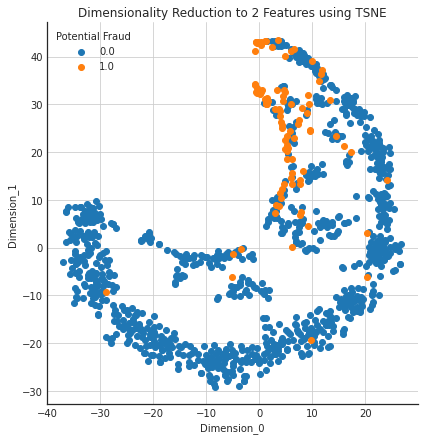

In [22]:
plot_TSNE(X_train_std, y_train)                                       # function call

#### 2.3.2 Perform PCA for Feature Reduction

AUROC scores for different values of features:
 [0.9345154917808202, 0.9389289464646803, 0.9392068302443995, 0.93821252459431, 0.9362089366455532, 0.9359669720266457, 0.9367193527310688, 0.9366715762302734, 0.9366109406401526, 0.9364977156891552, 0.9365648576908437, 0.9364749630852888, 0.93651885160844, 0.93642888013598, 0.9364522873483274, 0.9364070127413093, 0.9363615844004816, 0.9365195062169208, 0.9365648576908437, 0.936498293430731, 0.936498293430731, 0.936498370297636, 0.9364063581328285, 0.9363835286620571, 0.9364975619553453, 0.9364536734321941]


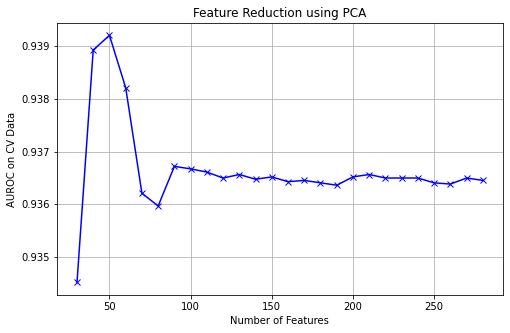

In [23]:
feat_reduct_PCA(X_train_std, X_cv_std, y_cv)                       # function call

#### 2.3.3 Replace Train and CV(Test) Data with the best features

In [24]:
imp_feat, X_train_std, X_cv_std = feat_after_reduction(50, X_train_std, X, X_train_df, X_cv_df)       # function call

Explained Variance using PCA with randomized svd_solver:
 [8.82397775e-01 7.92494714e-02 2.82495393e-02 3.37241801e-03
 1.43090328e-03 7.97860813e-04 7.66142435e-04 4.87417064e-04
 4.34161570e-04 3.19817772e-04 2.98542825e-04 2.52433423e-04
 1.74544207e-04 1.51863164e-04 1.42711485e-04 1.24305398e-04
 1.14823110e-04 9.95829469e-05 8.66522669e-05 7.39497084e-05
 6.93417884e-05 6.20350118e-05 5.61802553e-05 4.99551089e-05
 4.21614102e-05 4.09007896e-05 3.94154187e-05 3.62059036e-05
 3.29159179e-05 3.09993645e-05 3.06458821e-05 2.83547479e-05
 2.76761477e-05 2.57963875e-05 2.45305679e-05 2.29993227e-05
 2.18204208e-05 2.09124941e-05 1.83547601e-05 1.66778252e-05
 1.63852074e-05 1.42865398e-05 1.33800820e-05 1.20143115e-05
 1.16953887e-05 1.06139924e-05 9.22270722e-06 8.91015767e-06
 8.29286778e-06 7.81962533e-06]


100%|██████████| 50/50 [00:00<00:00, 31310.12it/s]


Unique Feature Names with best Explained Variance Ratio:
 ['mean_Hospital_Days_perBeneID', 'mean_DeductibleAmtPaid_perAttendingPhysician', 'Claim_Days', 'mean_Hospital_Days_perClmDiagnosisCode_3', 'mean_InscClaimAmtReimbursed_perOperatingPhysician', 'Race_3', 'count_ClaimID_perProviderOtherPhysician', 'count_ClaimID_perProviderAttendingPhysician', 'mean_DeductibleAmtPaid_perBeneID', 'mean_Hospital_Days_perClmProcedureCode_1', 'mean_Hospital_Days_perClmDiagnosisCode_10', 'mean_IPAnnualDeductibleAmt_perOperatingPhysician', 'mean_IPAnnualReimbursementAmt_perBeneID', 'mean_InscClaimAmtReimbursed_perOtherPhysician', 'mean_Hospital_Days_perOtherPhysician', 'mean_Hospital_Days_perOperatingPhysician', 'mean_Hospital_Days_perClmDiagnosisCode_8', 'Race_2', 'mean_Hospital_Days_perClmDiagnosisCode_4', 'Difference', 'ChronicCond_KidneyDisease', 'ChronicCond_ObstrPulmonary', 'Race_5', 'mean_Hospital_Days_perClmDiagnosisCode_6', 'count_ClaimID_perProviderClmDiagnosisCode_4', 'mean_IPAnnualReimbursem

#### 2.3.4 Store the Train and CV(Test) Data as csv for future use

In [25]:
X_train_std_df = pd.DataFrame(X_train_std, columns=imp_feat)                   # store Final X_train as dataframe 
X_cv_std_df = pd.DataFrame(X_cv_std, columns=imp_feat)                         # store Final X_cv as dataframe 
x_pf = pd.DataFrame(y_train, columns = ['PotentialFraud'])
X_train_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                # store y_train in Final X_train dataframe
x_pf = pd.DataFrame(y_cv, columns = ['PotentialFraud'])
X_cv_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                   # store y_cv in Final X_cv dataframe

X_train_std_df.to_csv('Final_train1.csv', index = False)                       # store important features as csv for X_train
X_cv_std_df.to_csv('Final_cv1.csv', index = False)                             # store important features as csv for X_cv

## 3. Modelling with Class Weight = 'Balanced'

In [26]:
def pred_proba(clf, data):
  '''Function takes classifier and train/cv data and returns the predicted probability'''
  y_pred = clf.predict_proba(data)[:,1]                                               # predict probability of Class 1

  return y_pred

def find_best_threshold(threshould, fpr, tpr):
    '''Calculates threshold with max value of exp: tpr(1-fpr)'''
    t = threshould[np.argmax(tpr*(1-fpr))]                                            # (tpr*(1-fpr)) = maximum if fpr = very low and tpr = very high

    return t

def predict_with_best_t(proba, threshould):
    '''Calculates predicted probability for best threshold'''
    predictions = []
    for i in proba:
        if i>=threshould:                                                             # predict 1 if above threshold
            predictions.append(1)                                                     # store value in list
        else:                                                                         # predict 0 if below threshold
            predictions.append(0)                                                     # store value in list
    return predictions

def plot_confusion_matrix(best_t, x_tr, x_cv, y_tr, y_cv, y_tr_pred, y_cv_pred):
    '''Function takes best threshold, train/cv data and predicted train/cv data and returns train/cv predictions along with the confusion matrix'''
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    cm = confusion_matrix(y_tr, predict_with_best_t(y_tr_pred, best_t))               # Calculate count of the confusion matrix for Train Data
    with plt.style.context('seaborn'):                                                # Set the background for graph plotting 
      sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='YlGnBu')                   # Plot Heatmap of Train Confusion Matrix
      ax[0].set_title('Train Confusion Matrix')                                       # Add title of the plot
      ax[0].set_xlabel('Predicted Values')                                            # Add label to x-axis
      ax[0].set_ylabel('Actual Values')                                               # Add label to y-axis
    
    cm = confusion_matrix(y_cv, predict_with_best_t(y_cv_pred, best_t))               # Calculate count of the confusion matrix for CV Data
    with plt.style.context('seaborn'):                                                # Set the background for graph plotting 
      sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cmap='YlGnBu')                   # Plot Heatmap of CV Confusion Matrix
      ax[1].set_title('CV Confusion Matrix')                                          # Add title of the plot
      ax[1].set_xlabel('Predicted Values')                                            # Add label to x-axis
      ax[1].set_ylabel('Actual Values')                                               # Add label to x-axis
        
    plt.show()
    
    return predict_with_best_t(y_tr_pred, best_t), predict_with_best_t(y_cv_pred, best_t)

def model_validation(clf, x_tr, x_cv, y_tr, y_cv):
  '''Function takes classifier, train and cv data and returns the best threshhold, model auc and train/cv f1 score'''
  y_tr_pred = pred_proba(clf, x_tr)                                                   # function call
  y_cv_pred = pred_proba(clf, x_cv)                                                   # function call
  train_fpr, train_tpr, tr_thresholds = roc_curve(y_tr, y_tr_pred)                    # Calculate FPR and TPR for Train Data
  cv_fpr, cv_tpr, cv_thresholds = roc_curve(y_cv, y_cv_pred)                          # Calculate FPR and TPR for CV Data

  print('Train AUC = {}'.format(auc(train_fpr, train_tpr)))
  print('CV AUC = {}'.format(auc(cv_fpr, cv_tpr)))

  plt.plot(train_fpr, train_tpr, label="Train AUC ="+str(auc(train_fpr, train_tpr))) # Plot Train FPR and Train TPR
  plt.plot(cv_fpr, cv_tpr, label="CV AUC ="+str(auc(cv_fpr, cv_tpr)))                # Plot CV FPR and CV TPR
  plt.legend()                                                                       # Add legend to the plot
  plt.plot([0,1],[0,1], 'g-')                                                        # Plot a diagnol for random model
  plt.xlabel("False positive Rate(FPR)")                                             # Add label to x-axis
  plt.ylabel("True positive Rate(TPR)")                                              # Add label to y-axis
  plt.title("ROC Curve")                                                             # Add title of the plot
  plt.grid()                                                                         # Add grid to the plot
  plt.show()

  best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)                  # function call
  tr_pred, cv_pred = plot_confusion_matrix(best_t, x_tr, x_cv, y_tr, y_cv, y_tr_pred, y_cv_pred)
  train_f1_score = f1_score(y_tr, tr_pred)                                           # calculate Train F1 score
  cv_f1_score = f1_score(y_cv, cv_pred)                                              # calculate cv F1 score

  return best_t, auc(cv_fpr, cv_tpr), train_f1_score, cv_f1_score

def imp_features(imp_feat, feat_weights, val, head):
  '''Function to predict the important features after applying a classification model on it'''
  feat_imp = pd.DataFrame(list(zip(imp_feat, feat_weights)), columns =['Features', 'Weights'])
  feat_imp = feat_imp[feat_imp['Weights'] != 0]                                     # Filter non zero weights of features with names
  feat_imp.reset_index(drop=True, inplace=True)

  best_worst_15_feat = feat_imp.sort_values(by= 'Weights',ascending=val)['Features'].iloc[0:15]
  best_worst_15_feat_weights = feat_imp.sort_values(by='Weights',ascending=val)['Weights'].iloc[0:15]
  feat_list = pd.DataFrame(list(zip(list(best_worst_15_feat), list(best_worst_15_feat_weights))), columns =['Features', 'Weights'])
  print(feat_list.head(15))

  with plt.style.context('seaborn-white'):                                          # Set the white background for graph plotting 
    plt.figure(figsize=(12, 8))
    sns.barplot(y=best_worst_15_feat, x=best_worst_15_feat_weights)                 # Bargraph with features and its weights
    plt.grid(linestyle="-")                                                         # Add grid to the plot
    plt.xlabel('Features Importance Weights')                                       # Add label to x-axis
    plt.ylabel('Features')                                                          # Add label to y-axis
    plt.title(head + 'Features')                                                    # Add title of the plot

  plt.show()

### 3.1 Logistic Regression with hyperparameter tuning using Random Search CV

In [27]:
# Code Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

reg_inv = np.logspace(-5,5,100)
print(reg_inv)
params ={'C':reg_inv, 'penalty':['l1','l2']}
model = LogisticRegression(tol=0.0001, 
                           fit_intercept=True, 
                           class_weight='balanced',
                           random_state=49,
                           solver='liblinear',
                           max_iter=500)

# Code Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

search = RandomizedSearchCV(model, params, scoring='roc_auc', cv=5, return_train_score=True)
result = search.fit(X_train_std, y_train)

print('Best Hyperparameters: ',result.best_params_)
print('Best Score: ',result.best_score_)

[1.00000000e-05 1.26185688e-05 1.59228279e-05 2.00923300e-05
 2.53536449e-05 3.19926714e-05 4.03701726e-05 5.09413801e-05
 6.42807312e-05 8.11130831e-05 1.02353102e-04 1.29154967e-04
 1.62975083e-04 2.05651231e-04 2.59502421e-04 3.27454916e-04
 4.13201240e-04 5.21400829e-04 6.57933225e-04 8.30217568e-04
 1.04761575e-03 1.32194115e-03 1.66810054e-03 2.10490414e-03
 2.65608778e-03 3.35160265e-03 4.22924287e-03 5.33669923e-03
 6.73415066e-03 8.49753436e-03 1.07226722e-02 1.35304777e-02
 1.70735265e-02 2.15443469e-02 2.71858824e-02 3.43046929e-02
 4.32876128e-02 5.46227722e-02 6.89261210e-02 8.69749003e-02
 1.09749877e-01 1.38488637e-01 1.74752840e-01 2.20513074e-01
 2.78255940e-01 3.51119173e-01 4.43062146e-01 5.59081018e-01
 7.05480231e-01 8.90215085e-01 1.12332403e+00 1.41747416e+00
 1.78864953e+00 2.25701972e+00 2.84803587e+00 3.59381366e+00
 4.53487851e+00 5.72236766e+00 7.22080902e+00 9.11162756e+00
 1.14975700e+01 1.45082878e+01 1.83073828e+01 2.31012970e+01
 2.91505306e+01 3.678379

#### 3.1.1 Fitting logistic regression with best hyperparameters

Train AUC = 0.9405512465419549
CV AUC = 0.9532094171526709


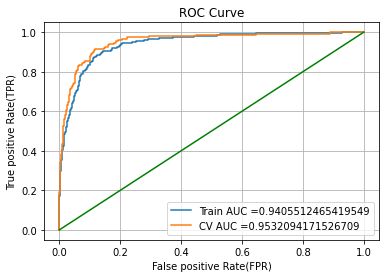

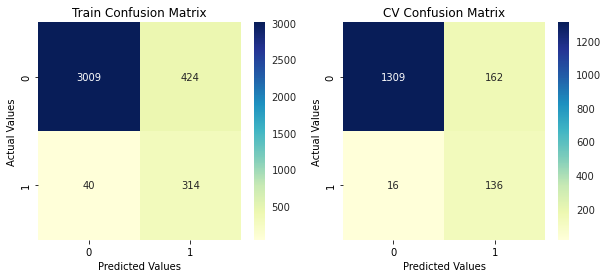

Best Threshold = 0.3709
Model AUC = 0.9532
Train F1 Score = 0.5751
CV F1 Score = 0.6044


In [28]:
model1 = LogisticRegression(penalty='l2',
                            C=0.4430621,
                            tol=0.0001,
                            fit_intercept=True,
                            class_weight='balanced',
                            random_state=49,
                            solver='liblinear',  
                            max_iter=500)

model1.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model1, X_train_std, X_cv_std, y_train, y_cv)     # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 3.1.2 Finding the most important features using logistic regression with best hyperparameters

                                             Features   Weights
0   mean_InscClaimAmtReimbursed_perOperatingPhysician  2.633486
1            mean_Hospital_Days_perAttendingPhysician  1.704703
2                     count_ClaimID_perProviderBeneID  1.657598
3       mean_InscClaimAmtReimbursed_perOtherPhysician  1.090961
4                                          Claim_Days  0.995610
5                               RenalDiseaseIndicator  0.838229
6            mean_Hospital_Days_perOperatingPhysician  0.689480
7            mean_Hospital_Days_perClmDiagnosisCode_5  0.620868
8            mean_DeductibleAmtPaid_perOtherPhysician  0.604518
9            mean_Hospital_Days_perClmDiagnosisCode_9  0.580291
10           mean_Hospital_Days_perClmDiagnosisCode_8  0.494931
11        count_ClaimID_perProviderClmDiagnosisCode_4  0.485881
12            count_ClaimID_perProviderOtherPhysician  0.429020
13           mean_Hospital_Days_perClmDiagnosisCode_2  0.410700
14                                      

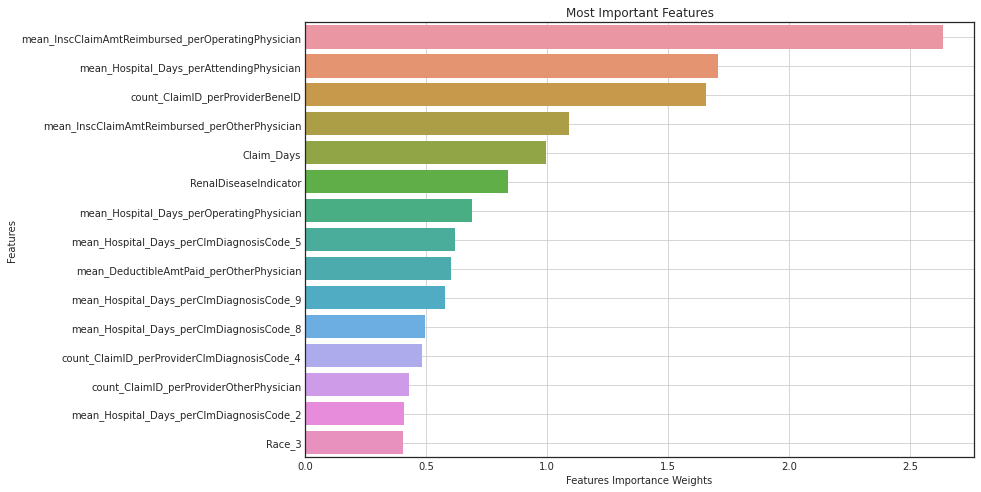

In [29]:
feat_weights = list(model1.coef_[0])
imp_features(imp_feat, feat_weights, False, 'Most Important ')            # function call

#### 3.1.3 Finding the least important features using logistic regression with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perClmDiagnosisCode_3 -1.329666
1                   mean_Claim_Days_perOtherPhysician -1.322850
2                    mean_DeductibleAmtPaid_perBeneID -0.863484
3                mean_Hospital_Days_perOtherPhysician -0.858212
4                               ChronicCond_Alzheimer -0.802235
5               mean_Claim_Days_perClmDiagnosisCode_1 -0.736349
6        mean_DeductibleAmtPaid_perOperatingPhysician -0.638207
7            mean_Hospital_Days_perClmDiagnosisCode_4 -0.527985
8            mean_Hospital_Days_perClmProcedureCode_1 -0.517320
9                           mean_Claim_Days_perBeneID -0.508628
10          mean_Hospital_Days_perClmDiagnosisCode_10 -0.368670
11  mean_InscClaimAmtReimbursed_perClmDiagnosisCode_4 -0.361220
12  mean_IPAnnualReimbursementAmt_perClmDiagnosisC... -0.324472
13       mean_DeductibleAmtPaid_perClmDiagnosisCode_9 -0.291266
14  mean_InscClaimAmtReimbursed_perClmDi

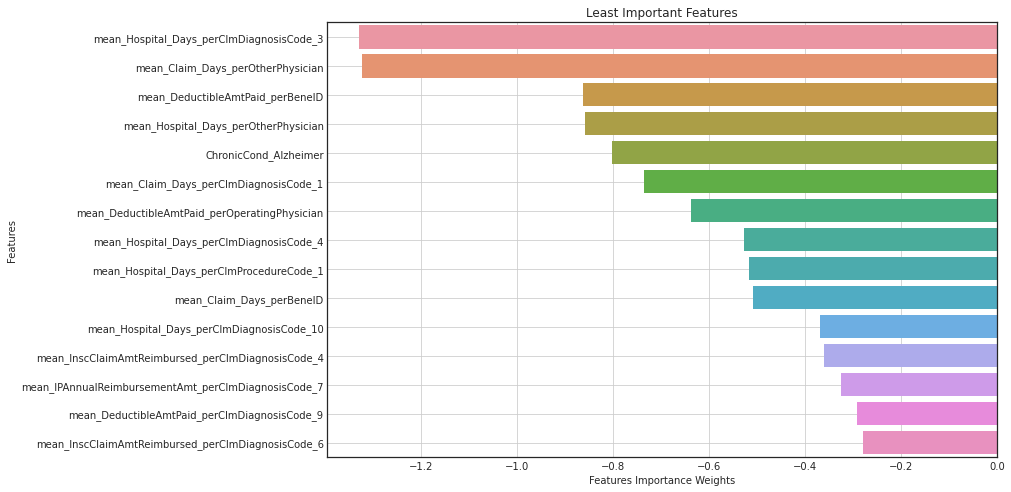

In [30]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')           # function call

#### 3.1.4 Summary of results

In [31]:
data = PrettyTable(['Model', 'Sampling Ratio', 'Solution for Imbalanced Data', 'Train AUC', 'CV AUC', 'Train F1 Score', 'CV F1 Score', 'False Negatives'])
data.add_row(['Logistic Regression', '70:30', 'Class Weight = Balanced', 0.9406, 0.9532, 0.5751, 0.6044, 16])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+


### 3.2 Decision Trees with hyperparameter tuning using Random Search CV

In [32]:
model2 = DecisionTreeClassifier(class_weight = 'balanced', random_state=49)

params = {'criterion': ['gini','entropy'],
          'max_depth': [int(a) for a in (np.linspace(2, 512, 200))],
          'min_samples_split': [int(a) for a in (np.linspace(10, 900, 80))],
          'min_samples_leaf': [int(a) for a in (np.linspace(10, 900, 80))],
          'max_features':["auto", "sqrt", "log2"]}

search1 = RandomizedSearchCV(model2, params, scoring='roc_auc', cv=5, return_train_score=True)

result1 = search1.fit(X_train_std, y_train)

print("Best Hyperparameters: ",result1.best_params_)
print("Best Score: ",result1.best_score_)

Best Hyperparameters:  {'min_samples_split': 381, 'min_samples_leaf': 246, 'max_features': 'sqrt', 'max_depth': 319, 'criterion': 'entropy'}
Best Score:  0.9083027792755404


#### 3.2.1 Fitting decision trees with best hyperparameters

Train AUC = 0.9127519374104117
CV AUC = 0.9264844001574295


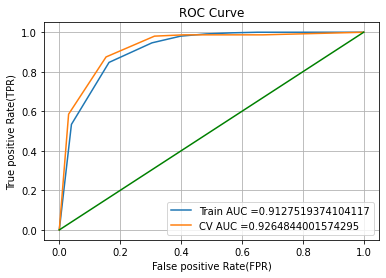

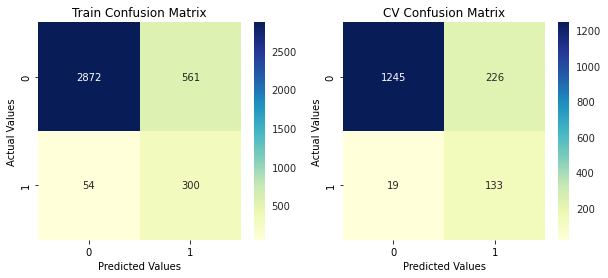

Best Threshold = 0.7174
Model AUC = 0.9265
Train F1 Score = 0.4938
CV F1 Score = 0.5205


In [33]:
model3 = DecisionTreeClassifier(criterion='gini',
                                max_depth= 178,
                                min_samples_split=122,
                                min_samples_leaf=280,
                                max_features='auto',
                                random_state=49,
                                class_weight='balanced')

model3.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model3, X_train_std, X_cv_std, y_train, y_cv)     # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 3.2.2 Finding the most important features using decision trees with best hyperparameters

                                            Features       Weights
0           mean_Hospital_Days_perClmDiagnosisCode_6  8.563762e-01
1  mean_InscClaimAmtReimbursed_perOperatingPhysician  7.713281e-02
2           mean_Hospital_Days_perAttendingPhysician  4.120890e-02
3                   mean_DeductibleAmtPaid_perBeneID  1.317692e-02
4  mean_IPAnnualReimbursementAmt_perClmDiagnosisC...  8.246778e-03
5           mean_Hospital_Days_perClmDiagnosisCode_4  2.304865e-03
6       mean_DeductibleAmtPaid_perAttendingPhysician  1.379161e-03
7           mean_Hospital_Days_perClmDiagnosisCode_8  1.743375e-04
8                                         Claim_Days  3.267085e-15


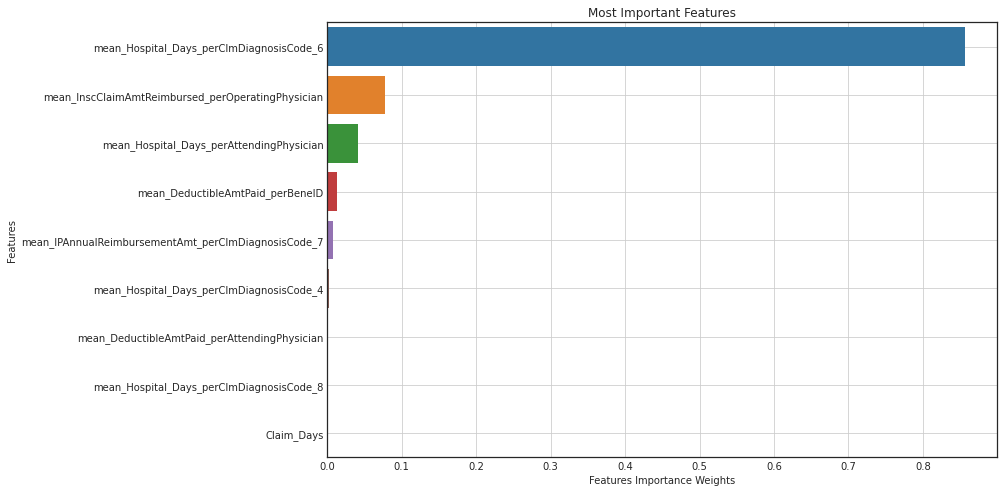

In [34]:
feat_weights = list(model3.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')            # function call

#### 3.2.3 Finding the least important features using decision trees with best hyperparameters

                                            Features       Weights
0                                         Claim_Days  3.267085e-15
1           mean_Hospital_Days_perClmDiagnosisCode_8  1.743375e-04
2       mean_DeductibleAmtPaid_perAttendingPhysician  1.379161e-03
3           mean_Hospital_Days_perClmDiagnosisCode_4  2.304865e-03
4  mean_IPAnnualReimbursementAmt_perClmDiagnosisC...  8.246778e-03
5                   mean_DeductibleAmtPaid_perBeneID  1.317692e-02
6           mean_Hospital_Days_perAttendingPhysician  4.120890e-02
7  mean_InscClaimAmtReimbursed_perOperatingPhysician  7.713281e-02
8           mean_Hospital_Days_perClmDiagnosisCode_6  8.563762e-01


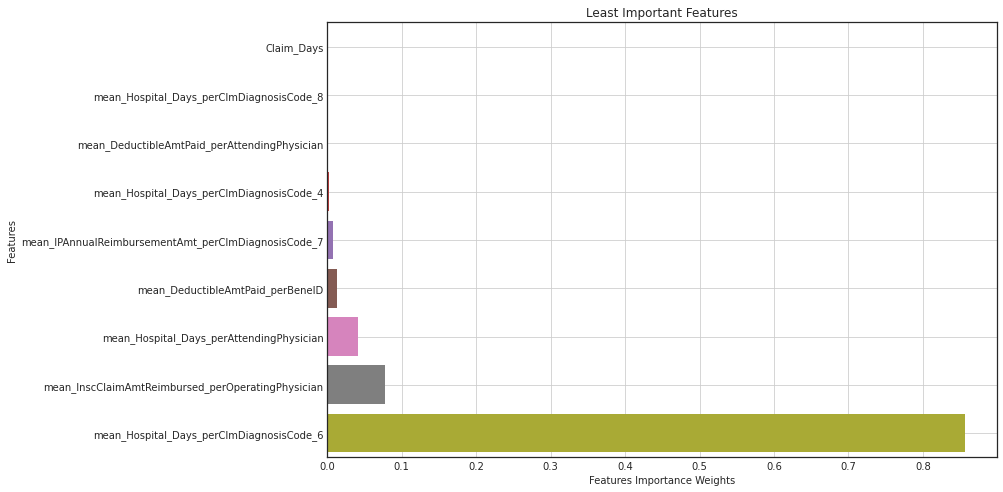

In [35]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')           # function call

#### 3.2.4 Summary of results and its comparison with other models

In [36]:
data.add_row(['Decision Trees', '70:30', 'Class Weight = Balanced', 0.9251, 0.9281, 0.5307, 0.5473, 16])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |   Class Weight = Balanced    |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+


### 3.3 XGB Classifier with hyperparameter tuning using Random Search CV

In [37]:
model4 = XGBClassifier(tree_method = 'hist')

params = {'n_estimators': [int(a) for a in (np.linspace(10, 500, 250))],
          'max_depth': [int(a) for a in (np.linspace(2, 512, 200))],
          'colsample_bytree': list(np.linspace(0.5, 1, 25)),
          'reg_alpha': [int(a) for a in (np.linspace(0, 100, 25))],
          'reg_lambda': [int(a) for a in (np.linspace(0, 100, 25))],
          'scale_pos_weight':[3.11, 9.69]}


search2 = RandomizedSearchCV(model4, params, scoring='roc_auc', cv=5, refit='recall', return_train_score=True)
result2 = search2.fit(X_train_std, y_train)

print("Best Hyperparameters: ",result2.best_params_)
print("Best Score: ",result2.best_score_)

Best Hyperparameters:  {'scale_pos_weight': 9.69, 'reg_lambda': 95, 'reg_alpha': 41, 'n_estimators': 271, 'max_depth': 504, 'colsample_bytree': 0.7708333333333333}
Best Score:  0.9244005081494521


#### 3.3.1 Fitting XGB Classifier with best hyperparameters

Train AUC = 0.9826097975613891
CV AUC = 0.9485066549787112


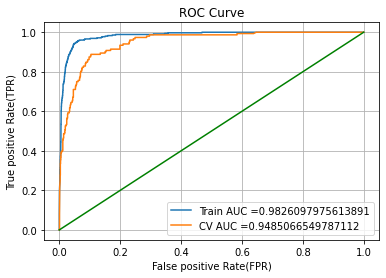

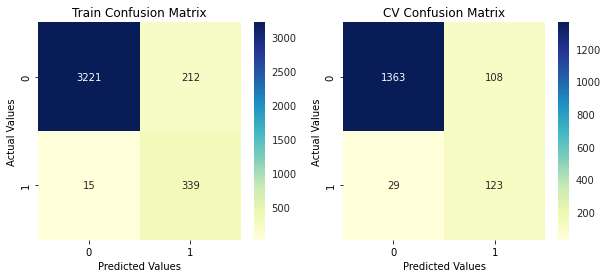

Best Threshold = 0.3838
Model AUC = 0.9485
Train F1 Score = 0.7492
CV F1 Score = 0.6423


In [38]:
model5 = XGBClassifier(n_estimators=263,
                       max_depth= 104,
                       colsample_bytree=0.83333,
                       reg_alpha=16,
                       reg_lambda=33,
                       random_state=49,
                       scale_pos_weight = 3.11)

model5.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model5, X_train_std, X_cv_std, y_train, y_cv)       # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 3.3.2 Finding the most important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perOperatingPhysician  0.597677
1        mean_DeductibleAmtPaid_perAttendingPhysician  0.080523
2            mean_Hospital_Days_perClmProcedureCode_1  0.079072
3   mean_InscClaimAmtReimbursed_perOperatingPhysician  0.025223
4            mean_Hospital_Days_perAttendingPhysician  0.016890
5                     count_ClaimID_perProviderBeneID  0.011322
6                          ChronicCond_ObstrPulmonary  0.008927
7           mean_Hospital_Days_perClmDiagnosisCode_10  0.007510
8   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_6  0.007181
9            mean_Hospital_Days_perClmDiagnosisCode_9  0.006889
10                              ChronicCond_Alzheimer  0.006515
11                                             Race_2  0.006145
12                                         Difference  0.005962
13                              RenalDiseaseIndicator  0.005843
14        count_ClaimID_perProviderDiagn

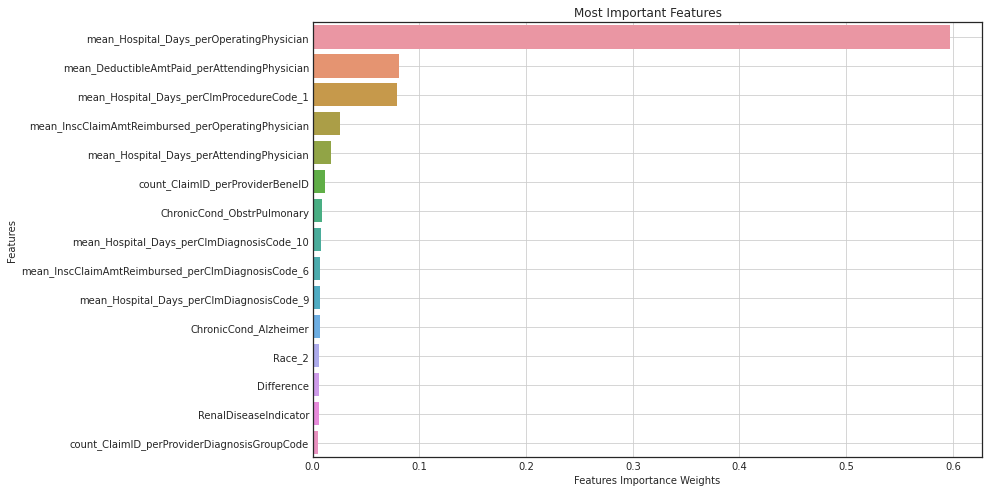

In [39]:
feat_weights = list(model5.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')            # function call

#### 3.3.3 Finding the least important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0   mean_IPAnnualReimbursementAmt_perClmDiagnosisC...  0.001253
1                           ChronicCond_KidneyDisease  0.002115
2            mean_DeductibleAmtPaid_perOtherPhysician  0.002343
3            mean_Hospital_Days_perClmDiagnosisCode_2  0.002448
4       mean_InscClaimAmtReimbursed_perOtherPhysician  0.002553
5                                  ChronicCond_Cancer  0.002598
6            mean_Hospital_Days_perClmDiagnosisCode_3  0.002785
7             count_ClaimID_perProviderOtherPhysician  0.002836
8         count_ClaimID_perProviderClmDiagnosisCode_4  0.003061
9            mean_Hospital_Days_perClmDiagnosisCode_5  0.003120
10                                             Race_3  0.003404
11                                         Claim_Days  0.003410
12       mean_IPAnnualDeductibleAmt_perOtherPhysician  0.003473
13               mean_Hospital_Days_perOtherPhysician  0.003508
14              mean_Claim_Days_perClmDi

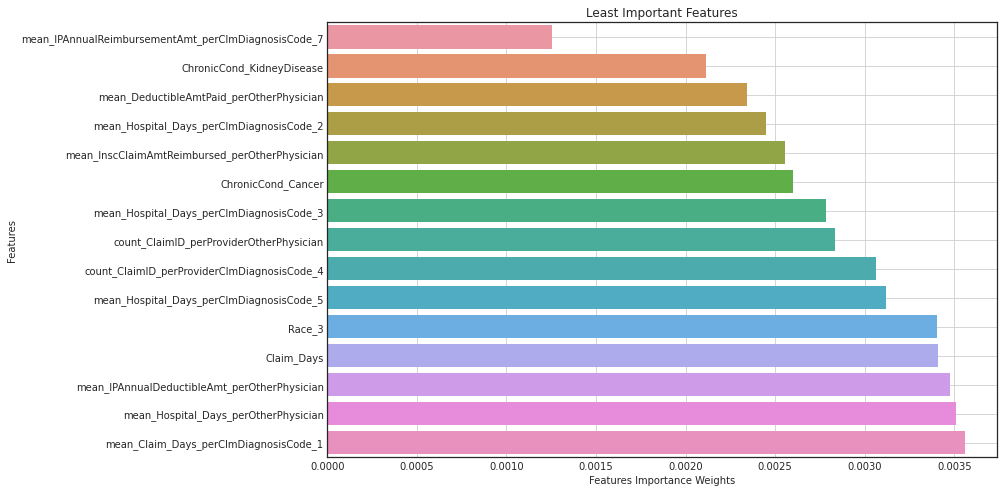

In [40]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')           # function call

#### 3.3.4 Summary of results and its comparison with other models

In [41]:
data.add_row(['XGBoost Classifier', '70:30', 'Scale Positive Weight', 0.9839, 0.9499, 0.7860, 0.6431, 34])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |   Class Weight = Balanced    |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |    Scale Positive Weight     |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+


## 4. Loading Data

### 4.1 Splitting and scaling data into Train and Cross Validation(or Test) 

#### 4.1.1 Stratified Sampling(80:20)

In [42]:
X_train_std, X_cv_std, y_train, y_cv, X_train_df, X_cv_df = train_cv_split_scaling(X, y, 0.20)         # function call
fraud_per(y_train)                                                                                     # function call

X_train Shape =  (4328, 285) 
X_cv Shape =  (1082, 285) 
Y_train Shape =  (4328,) 
Y_cv Shape =  (1082,)
Fraud Percentage = 9.36% 
Non-Fraud Percentage = 90.64%


### 4.2 Perform Dimensionality Reduction Techniques

#### 4.2.1 Plot TSNE for Train Data (285 dimensions reduced to 2 dimension)

<Figure size 576x360 with 0 Axes>

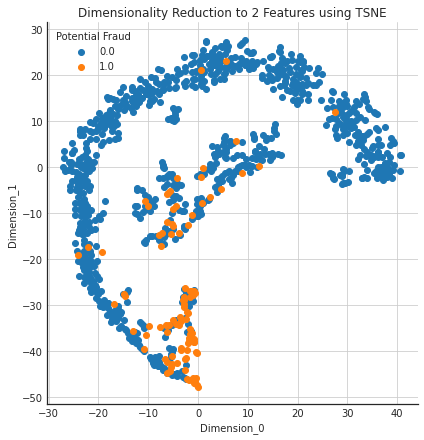

In [43]:
plot_TSNE(X_train_std, y_train)                                         # function call

#### 4.2.2 Perform PCA for Feature Reduction

AUROC scores for different values of features:
 [0.904982906868331, 0.9119458791493391, 0.90978271003833, 0.9086758742655873, 0.9084783043021414, 0.9089007858400793, 0.909299230932402, 0.9091415696082639, 0.9090416993483398, 0.9091439991515099, 0.9090997493993971, 0.9089977085830707, 0.9091947605728297, 0.9091974491029189, 0.909049246964921, 0.9091439991515099, 0.9092411808813445, 0.9090954082865924, 0.9090489879780774, 0.909250899054328, 0.9089957970135117, 0.9091950195596731, 0.9093966716490802, 0.9091947605728297, 0.9091420875819509, 0.9092411808813445]


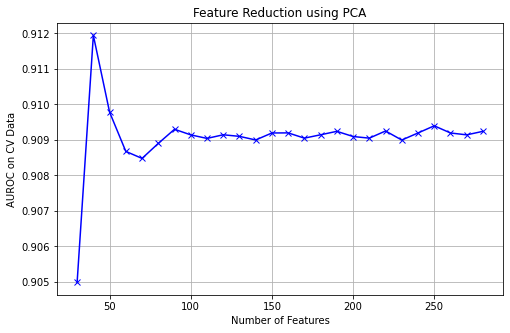

In [44]:
feat_reduct_PCA(X_train_std, X_cv_std, y_cv)                           # function call

#### 4.2.3 Replace Train and CV(Test) Data with the best features

In [45]:
imp_feat, X_train_std, X_cv_std = feat_after_reduction(40, X_train_std, X, X_train_df, X_cv_df)         # function call

Explained Variance using PCA with randomized svd_solver:
 [8.80645223e-01 7.97950865e-02 2.91801872e-02 3.37547333e-03
 1.47755314e-03 8.14285439e-04 7.81602778e-04 5.11610419e-04
 4.55513793e-04 3.38165478e-04 3.10312925e-04 2.66482400e-04
 1.92167659e-04 1.57147934e-04 1.46997005e-04 1.27901506e-04
 1.18156487e-04 1.04686257e-04 9.02939860e-05 7.60360611e-05
 7.09398597e-05 6.47652958e-05 5.93761699e-05 5.27620050e-05
 4.44571859e-05 4.36023777e-05 4.26344109e-05 3.87154456e-05
 3.53027182e-05 3.35564305e-05 3.21439132e-05 3.09132788e-05
 2.99041919e-05 2.69262301e-05 2.59087062e-05 2.50631228e-05
 2.41708240e-05 2.23139032e-05 1.89314834e-05 1.74521915e-05]


100%|██████████| 40/40 [00:00<00:00, 9875.34it/s]


Unique Feature Names with best Explained Variance Ratio:
 ['mean_Hospital_Days_perBeneID', 'mean_DeductibleAmtPaid_perAttendingPhysician', 'mean_Hospital_Days_perProvider', 'mean_Hospital_Days_perClmDiagnosisCode_3', 'mean_InscClaimAmtReimbursed_perClmDiagnosisCode_5', 'Race_3', 'count_ClaimID_perProviderAttendingPhysician', 'mean_Hospital_Days_perClmProcedureCode_1', 'mean_OPAnnualReimbursementAmt_perProvider', 'mean_Hospital_Days_perOperatingPhysician', 'mean_Hospital_Days_perOtherPhysician', 'Race_2', 'mean_Claim_Days_perProvider', 'mean_Hospital_Days_perClmDiagnosisCode_4', 'Difference', 'ChronicCond_ObstrPulmonary', 'Race_5', 'mean_Hospital_Days_perClmDiagnosisCode_6', 'count_ClaimID_perProviderClmDiagnosisCode_4', 'mean_IPAnnualReimbursementAmt_perClmDiagnosisCode_7', 'mean_Hospital_Days_perClmDiagnosisCode_9', 'RenalDiseaseIndicator', 'mean_DeductibleAmtPaid_perClmAdmitDiagnosisCode', 'ChronicCond_stroke', 'Gender_0', 'mean_Hospital_Days_perAttendingPhysician', 'mean_InscClaimA

#### 4.2.4 Store the Train and CV(Test) Data as csv for future use

In [46]:
X_train_std_df = pd.DataFrame(X_train_std, columns=imp_feat)                   # store Final X_train as dataframe 
X_cv_std_df = pd.DataFrame(X_cv_std, columns=imp_feat)                         # store Final X_cv as dataframe 
x_pf = pd.DataFrame(y_train, columns = ['PotentialFraud'])
X_train_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                # store y_train in Final X_train dataframe
x_pf = pd.DataFrame(y_cv, columns = ['PotentialFraud'])
X_cv_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                   # store y_cv in Final X_cv dataframe

X_train_std_df.to_csv('Final_train2.csv', index = False)                       # store important features as csv for X_train
X_cv_std_df.to_csv('Final_cv2.csv', index = False)                             # store important features as csv for X_cv

## 5. Modelling with Class Weight = 'Balanced'

### 5.1 Fitting logistic regression with best hyperparameters

Train AUC = 0.9434704481012579
CV AUC = 0.9482342729685812


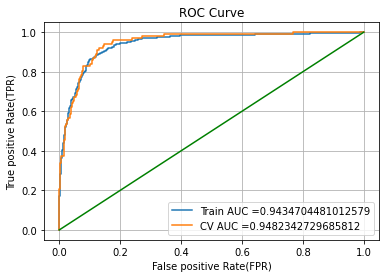

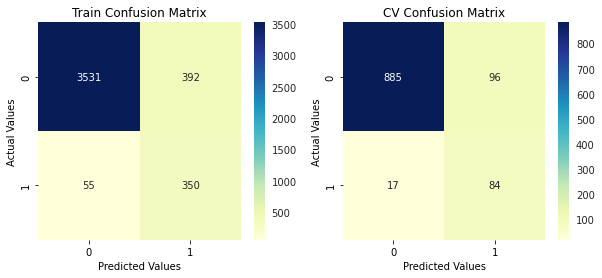

Best Threshold = 0.4236
Model AUC = 0.9482
Train F1 Score = 0.6103
CV F1 Score = 0.5979


In [47]:
model1 = LogisticRegression(penalty='l2',
                            C=0.4430621,
                            tol=0.0001,
                            fit_intercept=True,
                            class_weight='balanced',
                            random_state=49,
                            solver='liblinear',  
                            max_iter=500)

model1.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model1, X_train_std, X_cv_std, y_train, y_cv)      # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 5.1.1 Finding the most important features using logistic regression with best hyperparameters

                                             Features   Weights
0                      mean_Hospital_Days_perProvider  2.479000
1                     count_ClaimID_perProviderBeneID  1.585827
2   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_5  0.995644
3            mean_DeductibleAmtPaid_perOtherPhysician  0.915326
4            mean_Hospital_Days_perAttendingPhysician  0.835897
5                               RenalDiseaseIndicator  0.795052
6            mean_Hospital_Days_perOperatingPhysician  0.725985
7            mean_Hospital_Days_perClmDiagnosisCode_9  0.631364
8            mean_Hospital_Days_perClmProcedureCode_2  0.606422
9                            IPAnnualReimbursementAmt  0.548731
10           mean_Hospital_Days_perClmDiagnosisCode_5  0.548685
11        count_ClaimID_perProviderClmDiagnosisCode_4  0.522942
12           mean_Hospital_Days_perClmDiagnosisCode_2  0.444753
13    mean_DeductibleAmtPaid_perClmAdmitDiagnosisCode  0.433466
14        count_ClaimID_perProviderDiagn

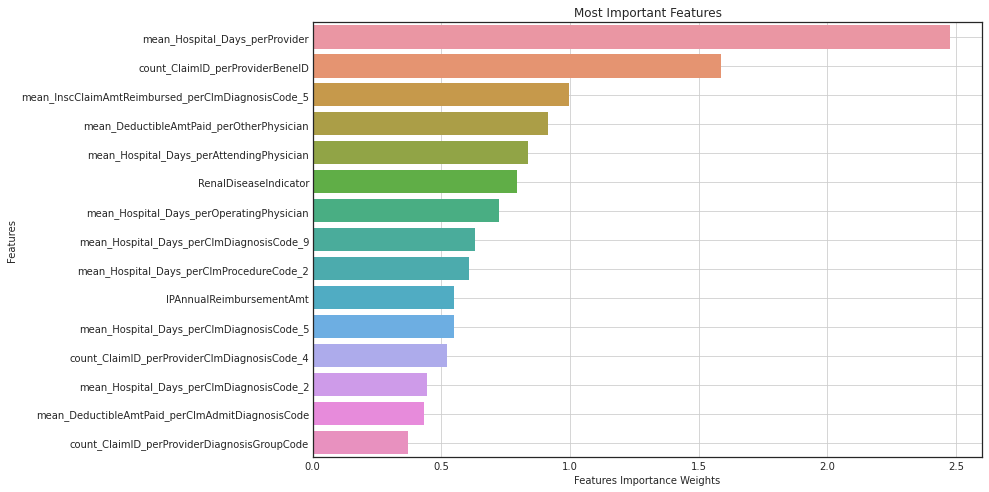

In [48]:
feat_weights = list(model1.coef_[0])

imp_features(imp_feat, feat_weights, False, 'Most Important ')        # function call

#### 5.1.2 Finding the least important features using logistic regression with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perClmDiagnosisCode_3 -1.431553
1                mean_Hospital_Days_perOtherPhysician -0.977838
2                                            Gender_0 -0.921287
3            mean_Hospital_Days_perClmDiagnosisCode_1 -0.753168
4            mean_Hospital_Days_perClmDiagnosisCode_4 -0.626537
5            mean_Hospital_Days_perClmDiagnosisCode_6 -0.608333
6        mean_DeductibleAmtPaid_perAttendingPhysician -0.565975
7                                            Gender_1 -0.512054
8   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_9 -0.389818
9                        mean_Hospital_Days_perBeneID -0.385710
10  mean_IPAnnualReimbursementAmt_perClmDiagnosisC... -0.365965
11                                             Race_2 -0.326657
12              mean_Claim_Days_perClmDiagnosisCode_2 -0.153694
13                         ChronicCond_ObstrPulmonary -0.053671
14       mean_DeductibleAmtPaid_perOpera

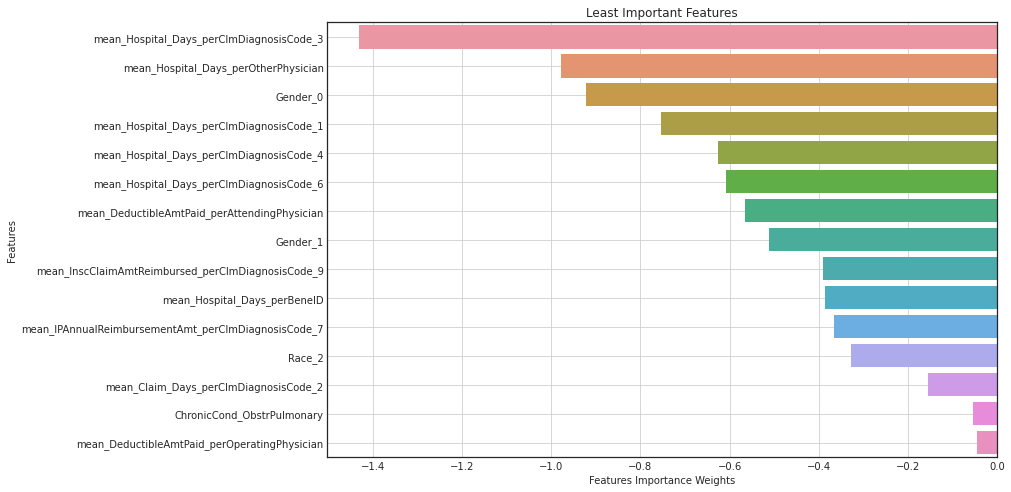

In [49]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')         # function call

#### 5.1.3 Summary of results and its comparison with other models

In [50]:
data.add_row(['Logistic Regression', '80:20', 'Class Weight = Balanced', 0.9435, 0.9482, 0.6103, 0.5979, 17])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |   Class Weight = Balanced    |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |    Scale Positive Weight     |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |   Class Weight = Balanced    |   0.9435  | 0.9482 |     0.6103     |    0.5979   |        17       |
+-----

### 5.2 Fitting decision trees with best hyperparameters

Train AUC = 0.9294615798566856
CV AUC = 0.9278115884982994


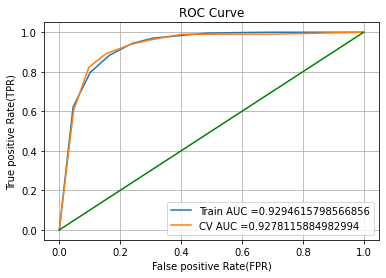

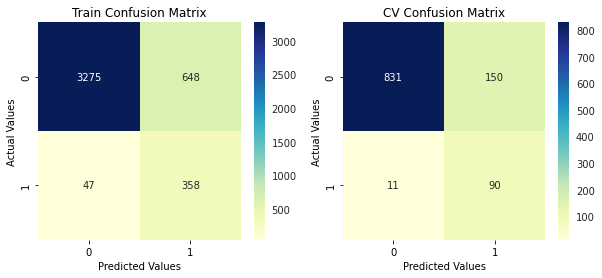

Best Threshold = 0.5775
Model AUC = 0.9278
Train F1 Score = 0.5074
CV F1 Score = 0.5279


In [51]:
model3 = DecisionTreeClassifier(criterion='gini',
                                max_depth= 178,
                                min_samples_split=122,
                                min_samples_leaf=280,
                                max_features='auto',
                                random_state=49,
                                class_weight='balanced')

model3.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model3, X_train_std, X_cv_std, y_train, y_cv)      # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 5.2.1 Finding the most important features using decision trees with best hyperparameters

                                       Features   Weights
0      mean_Hospital_Days_perClmProcedureCode_1  0.864382
1  mean_DeductibleAmtPaid_perAttendingPhysician  0.066772
2      mean_Hospital_Days_perClmDiagnosisCode_9  0.049287
3      mean_Hospital_Days_perAttendingPhysician  0.009667
4                  mean_Hospital_Days_perBeneID  0.005045
5                                      Gender_1  0.002780
6      mean_Hospital_Days_perClmDiagnosisCode_2  0.002067


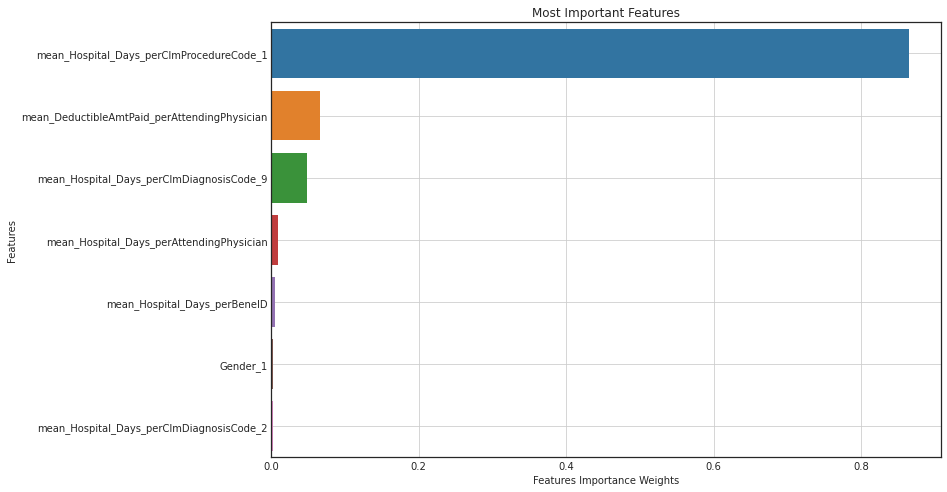

In [52]:
feat_weights = list(model3.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')              # function call

#### 5.2.2 Finding the least important features using decision trees with best hyperparameters

                                       Features   Weights
0      mean_Hospital_Days_perClmDiagnosisCode_2  0.002067
1                                      Gender_1  0.002780
2                  mean_Hospital_Days_perBeneID  0.005045
3      mean_Hospital_Days_perAttendingPhysician  0.009667
4      mean_Hospital_Days_perClmDiagnosisCode_9  0.049287
5  mean_DeductibleAmtPaid_perAttendingPhysician  0.066772
6      mean_Hospital_Days_perClmProcedureCode_1  0.864382


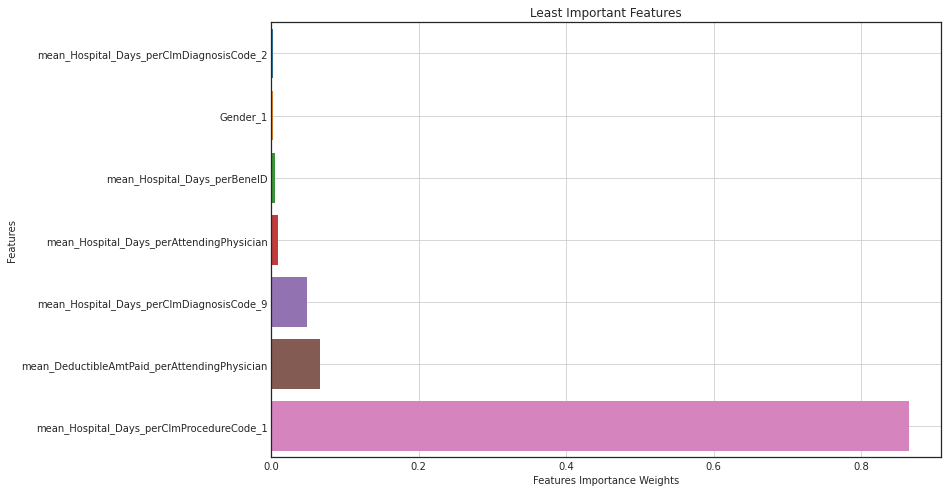

In [53]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')         # function call

#### 5.2.3 Summary of results and its comparison with other models

In [54]:
data.add_row(['Decision Trees', '80:20', 'Class Weight = Balanced', 0.9236, 0.9156, 0.5830, 0.5843, 23])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |   Class Weight = Balanced    |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |    Scale Positive Weight     |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |   Class Weight = Balanced    |   0.9435  | 0.9482 |     0.6103     |    0.5979   |        17       |
|    D

### 5.3 Fitting XGB Classifier with best hyperparameters

Train AUC = 0.9852267255784971
CV AUC = 0.9419666737315934


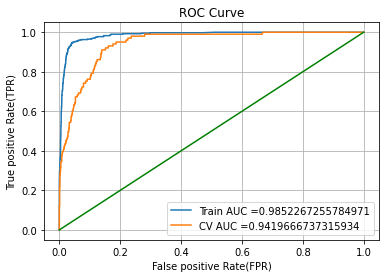

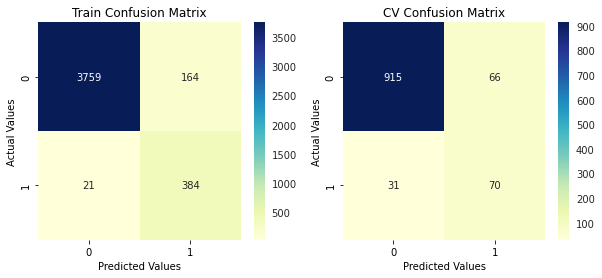

Best Threshold = 0.4415
Model AUC = 0.9420
Train F1 Score = 0.8059
CV F1 Score = 0.5907


In [55]:
model5 = XGBClassifier(n_estimators=263,
                       max_depth= 104,
                       colsample_bytree=0.83333,
                       reg_alpha=16,
                       reg_lambda=33,
                       random_state=49,
                       scale_pos_weight= 3.11)

model5.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model5, X_train_std, X_cv_std, y_train, y_cv)         # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 5.3.1 Finding the most important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perOperatingPhysician  0.672692
1            mean_Hospital_Days_perClmProcedureCode_1  0.044376
2        mean_DeductibleAmtPaid_perAttendingPhysician  0.029214
3                      mean_Hospital_Days_perProvider  0.028817
4            mean_Hospital_Days_perClmDiagnosisCode_9  0.025181
5   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_5  0.012629
6        mean_DeductibleAmtPaid_perOperatingPhysician  0.011770
7            mean_Hospital_Days_perClmDiagnosisCode_5  0.011285
8                     count_ClaimID_perProviderBeneID  0.010243
9            mean_Hospital_Days_perClmDiagnosisCode_4  0.009212
10        count_ClaimID_perProviderDiagnosisGroupCode  0.007680
11           mean_Hospital_Days_perClmDiagnosisCode_1  0.007136
12                                         Difference  0.007007
13           mean_Hospital_Days_perAttendingPhysician  0.006807
14  mean_InscClaimAmtReimbursed_perClmDi

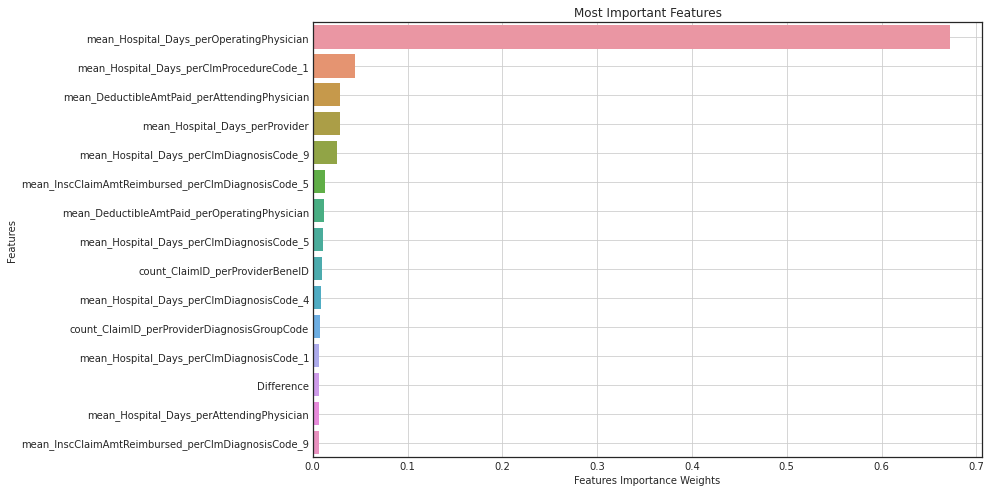

In [56]:
feat_weights = list(model5.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')             # function call

#### 5.3.2 Finding the least important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0   mean_IPAnnualReimbursementAmt_perClmDiagnosisC...  0.001600
1                            ChronicCond_Osteoporasis  0.002339
2                                            Gender_1  0.002979
3                                              Race_3  0.003127
4                          ChronicCond_ObstrPulmonary  0.003354
5            mean_Hospital_Days_perClmDiagnosisCode_2  0.003498
6                                            Gender_0  0.003733
7         count_ClaimID_perProviderAttendingPhysician  0.003755
8                              ChronicCond_Depression  0.003780
9                mean_Hospital_Days_perOtherPhysician  0.004086
10           mean_Hospital_Days_perClmDiagnosisCode_3  0.004162
11                           IPAnnualReimbursementAmt  0.004379
12           mean_Hospital_Days_perClmDiagnosisCode_6  0.004487
13           mean_Hospital_Days_perClmProcedureCode_2  0.004491
14                                      

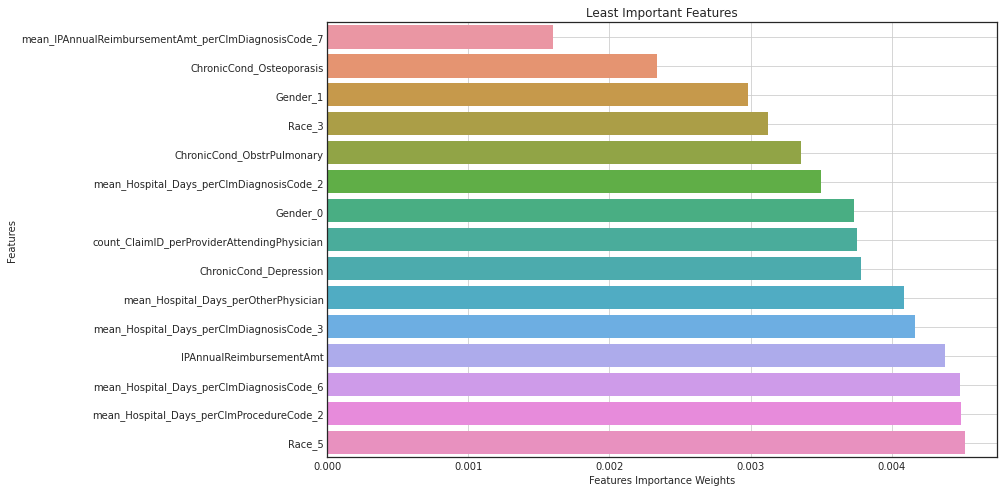

In [57]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')         # function call

#### 5.3.3 Summary of results and its comparison with other models

In [58]:
data.add_row(['XGBoost Classifier', '80:20', 'Scale Positive Weight', 0.9822, 0.9426, 0.7954, 0.5917, 30])

print(data)

+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio | Solution for Imbalanced Data | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |   Class Weight = Balanced    |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |   Class Weight = Balanced    |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |    Scale Positive Weight     |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |   Class Weight = Balanced    |   0.9435  | 0.9482 |     0.6103     |    0.5979   |        17       |
|    D

## 6. Loading Data

### 6.1 Splitting and scaling data into Train and Cross Validation(or Test) 

#### 6.1.1 Stratified Sampling(70:30)

In [59]:
X_train_std, X_cv_std, y_train, y_cv, X_train_df, X_cv_df = train_cv_split_scaling(X, y, 0.30)       # function call

X_train Shape =  (3787, 285) 
X_cv Shape =  (1623, 285) 
Y_train Shape =  (3787,) 
Y_cv Shape =  (1623,)


### 6.2 SMOTE Sampling(70:30) for Imbalanced Data

In [60]:
# Code Reference: https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

oversample = SMOTE(sampling_strategy=0.428)
X_train_sample, y_train = oversample.fit_resample(X_train_std, y_train)
print(X_train_sample.shape, y_train.shape)
fraud_per(y_train)

(4902, 285) (4902,)
Fraud Percentage = 29.97% 
Non-Fraud Percentage = 70.03%


### 6.3 Perform Dimensionality Reduction Techniques

#### 6.3.1 Plot TSNE for Train Data (285 dimensions reduced to 2 dimension)

<Figure size 576x360 with 0 Axes>

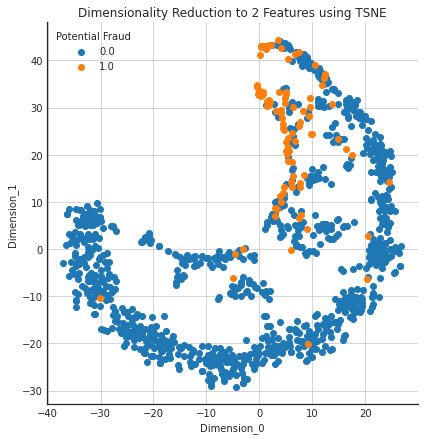

In [61]:
plot_TSNE(X_train_sample, y_train)                                               # function call

#### 6.3.2 Perform PCA for Feature Reduction

AUROC scores for different values of features:
 [0.9353586522999942, 0.9387314853041635, 0.9387148547773402, 0.9381064606633613, 0.9369536554552566, 0.9362806981002716, 0.9364231051997983, 0.9367234341157641, 0.9365859936101286, 0.9366108637732475, 0.9364063581328285, 0.9365202376923067, 0.9364546355082949, 0.9362723444034075, 0.9364516327398464, 0.936588341770096, 0.93651885160844, 0.9365423356876923, 0.936474231609903, 0.9364999101153128, 0.9363163866603685, 0.9364522873483274, 0.9363170412688493, 0.9364296884782709, 0.9364983702976362, 0.9364757714275797]


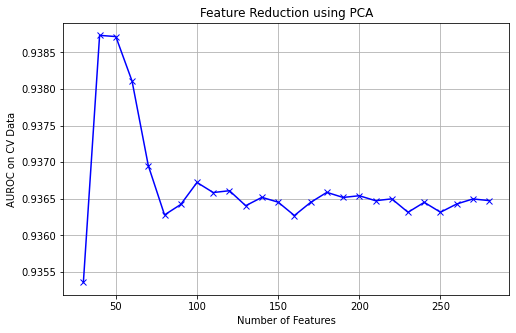

In [62]:
feat_reduct_PCA(X_train_sample, X_cv_std, y_cv)                                   # function call

#### 6.3.3 Replace Train and CV(Test) Data with the best features

In [63]:
X_train_df = pd.DataFrame(X_train_sample, columns=X.columns)
X_cv_df = pd.DataFrame(X_cv_std, columns=X.columns)
print(X_train_df.shape, X_cv_df.shape)

imp_feat, X_train_std, X_cv_std = feat_after_reduction(50, X_train_sample, X, X_train_df, X_cv_df)       # function call

(4902, 285) (1623, 285)
Explained Variance using PCA with randomized svd_solver:
 [8.91659633e-01 8.32592322e-02 1.49897726e-02 4.05063296e-03
 1.68282398e-03 1.04548285e-03 6.01473339e-04 3.71196414e-04
 3.41068309e-04 2.37858930e-04 2.26241665e-04 1.99499847e-04
 1.21399476e-04 1.15999841e-04 1.01635343e-04 9.68640341e-05
 8.20650325e-05 6.74968895e-05 5.58630841e-05 5.09753615e-05
 4.52313091e-05 4.15115741e-05 3.85250425e-05 3.45816404e-05
 2.99108913e-05 2.80702848e-05 2.57761228e-05 2.42100753e-05
 2.18759045e-05 2.08393428e-05 1.99551961e-05 1.86719022e-05
 1.82061652e-05 1.77383676e-05 1.55511136e-05 1.48188562e-05
 1.34490891e-05 1.27060394e-05 1.23646524e-05 1.17039323e-05
 1.02991980e-05 8.97140835e-06 8.29259699e-06 7.72178278e-06
 7.27931839e-06 6.37248170e-06 6.32475731e-06 6.21353053e-06
 5.90850502e-06 5.52945982e-06]


100%|██████████| 50/50 [00:00<00:00, 19362.50it/s]


Unique Feature Names with best Explained Variance Ratio:
 ['mean_Hospital_Days_perBeneID', 'mean_DeductibleAmtPaid_perAttendingPhysician', 'Claim_Days', 'mean_Hospital_Days_perClmDiagnosisCode_3', 'mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3', 'count_ClaimID_perProviderClmDiagnosisCode_1', 'mean_Hospital_Days_perClmAdmitDiagnosisCode', 'count_ClaimID_perProviderAttendingPhysician', 'mean_Claim_Days_perOperatingPhysician', 'count_ClaimID_perProviderOtherPhysician', 'Race_3', 'mean_IPAnnualReimbursementAmt_perOperatingPhysician', 'mean_DeductibleAmtPaid_perBeneID', 'mean_OPAnnualReimbursementAmt_perProvider', 'mean_Hospital_Days_perClmProcedureCode_1', 'mean_Hospital_Days_perClmDiagnosisCode_10', 'mean_InscClaimAmtReimbursed_perOtherPhysician', 'mean_Hospital_Days_perOtherPhysician', 'mean_Hospital_Days_perOperatingPhysician', 'Race_2', 'mean_Hospital_Days_perClmDiagnosisCode_4', 'Difference', 'ChronicCond_KidneyDisease', 'ChronicCond_ObstrPulmonary', 'mean_InscClaimAmtReimbursed_

#### 6.3.4 Store the Train and CV(Test) Data as csv for future use

In [64]:
X_train_std_df = pd.DataFrame(X_train_std, columns=imp_feat)                   # store Final X_train as dataframe 
X_cv_std_df = pd.DataFrame(X_cv_std, columns=imp_feat)                         # store Final X_cv as dataframe 
x_pf = pd.DataFrame(y_train, columns = ['PotentialFraud'])
X_train_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                # store y_train in Final X_train dataframe
x_pf = pd.DataFrame(y_cv, columns = ['PotentialFraud'])
X_cv_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                   # store y_cv in Final X_cv dataframe

X_train_std_df.to_csv('Final_train3.csv', index = False)                       # store important features as csv for X_train
X_cv_std_df.to_csv('Final_cv3.csv', index = False)                             # store important features as csv for X_cv

## 7. Modelling with Synthetic Minority Oversampling
### 7.1 Fitting logistic regression with best hyperparameters

Train AUC = 0.9439211417949797
CV AUC = 0.9482763247343375


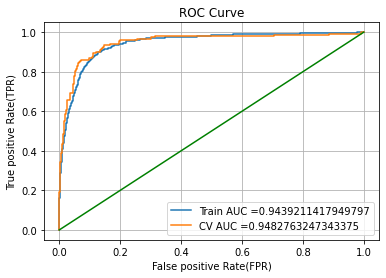

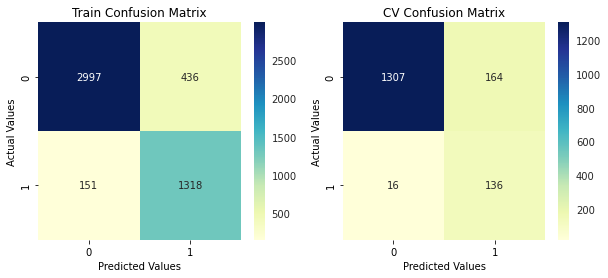

Best Threshold = 0.3536
Model AUC = 0.9483
Train F1 Score = 0.8179
CV F1 Score = 0.6018


In [65]:
model1 = LogisticRegression(penalty='l2',
                            C=0.4430621,
                            tol=0.0001,
                            fit_intercept=True,
                            class_weight='balanced',
                            random_state=49,
                            solver='liblinear',  
                            max_iter=200)

model1.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model1, X_train_std, X_cv_std, y_train, y_cv)      # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 7.1.1 Finding the most important features using logistic regression with best hyperparameters

                                             Features   Weights
0       mean_InscClaimAmtReimbursed_perOtherPhysician  2.120344
1            mean_Hospital_Days_perAttendingPhysician  1.948105
2   mean_InscClaimAmtReimbursed_perClmProcedureCode_1  1.891353
3                     count_ClaimID_perProviderBeneID  1.720764
4            mean_Hospital_Days_perOperatingPhysician  1.045501
5            mean_Hospital_Days_perClmDiagnosisCode_2  0.912501
6               mean_InscClaimAmtReimbursed_perBeneID  0.906271
7         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.850188
8   mean_InscClaimAmtReimbursed_perClmProcedureCode_2  0.816651
9                            ChronicCond_Heartfailure  0.640451
10           mean_Hospital_Days_perClmDiagnosisCode_5  0.614499
11    mean_DeductibleAmtPaid_perClmAdmitDiagnosisCode  0.588967
12           mean_DeductibleAmtPaid_perOtherPhysician  0.574505
13                              RenalDiseaseIndicator  0.559321
14        count_ClaimID_perProviderClmDi

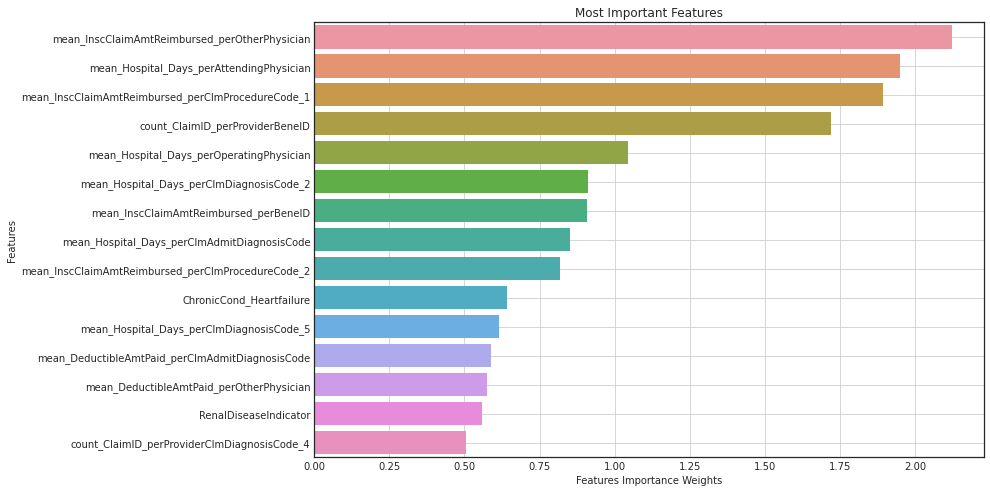

In [66]:
feat_weights = list(model1.coef_[0])
imp_features(imp_feat, feat_weights, False, 'Most Important ')                     # function call

#### 7.1.2 Finding the least important features using logistic regression with best hyperparameters

                                             Features   Weights
0                mean_Hospital_Days_perOtherPhysician -1.397637
1   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3 -1.382005
2            mean_Hospital_Days_perClmDiagnosisCode_3 -1.360475
3                    mean_DeductibleAmtPaid_perBeneID -1.253006
4                                            Gender_0 -1.184100
5            mean_Hospital_Days_perClmDiagnosisCode_4 -1.095195
6            mean_Hospital_Days_perClmProcedureCode_1 -0.940155
7            mean_Hospital_Days_perClmProcedureCode_3 -0.843375
8                               ChronicCond_Alzheimer -0.638911
9               mean_Claim_Days_perOperatingPhysician -0.596761
10       mean_DeductibleAmtPaid_perOperatingPhysician -0.478366
11          mean_Hospital_Days_perClmDiagnosisCode_10 -0.439447
12       mean_DeductibleAmtPaid_perAttendingPhysician -0.366275
13  mean_InscClaimAmtReimbursed_perClmDiagnosisCode_4 -0.362628
14                                      

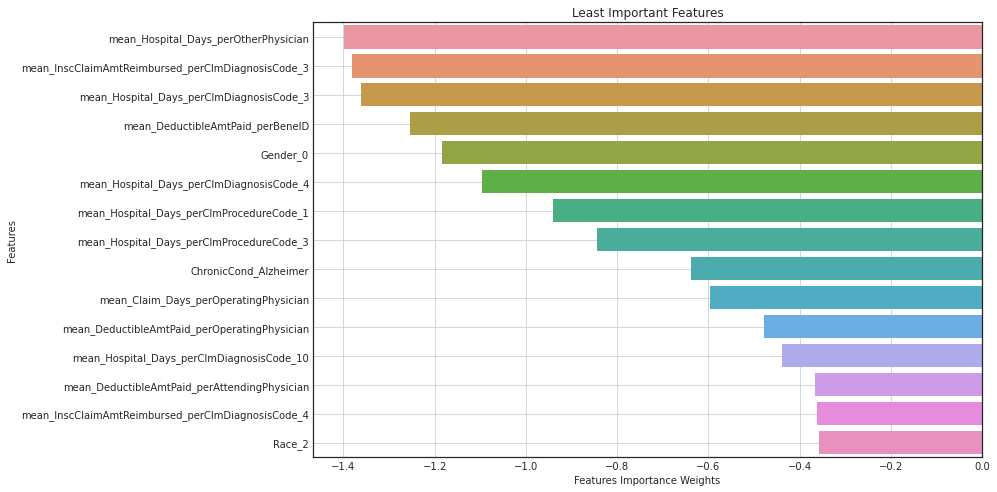

In [67]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')                # function call

#### 7.1.3 Summary of results and its comparison with other models

In [68]:
data.add_row(['Logistic Regression', '70:30', 'Synthetic Minority Oversampling', 0.9439, 0.9483, 0.8179, 0.6018, 16])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

### 7.2 Fitting decision trees with best hyperparameters

Train AUC = 0.9339257560414009
CV AUC = 0.9300310386775914


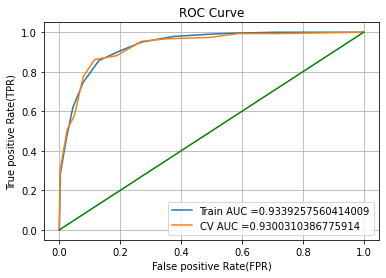

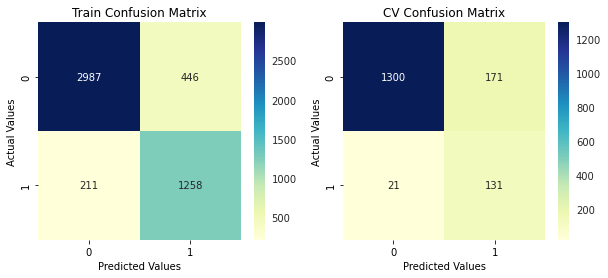

Best Threshold = 0.6813
Model AUC = 0.9300
Train F1 Score = 0.7929
CV F1 Score = 0.5771


In [69]:
model3 = DecisionTreeClassifier(criterion='gini',
                                max_depth= 178,
                                min_samples_split=122,
                                min_samples_leaf=280,
                                max_features='auto',
                                random_state=49,
                                class_weight='balanced')

model3.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model3, X_train_std, X_cv_std, y_train, y_cv)       # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 7.2.1 Finding the most important features using decision trees with best hyperparameters

                                            Features   Weights
0  mean_InscClaimAmtReimbursed_perClmProcedureCode_1  0.822440
1           mean_Hospital_Days_perOperatingPhysician  0.086056
2           mean_Hospital_Days_perClmDiagnosisCode_6  0.045054
3            count_ClaimID_perProviderOtherPhysician  0.020732
4        mean_Hospital_Days_perClmAdmitDiagnosisCode  0.012308
5                           ChronicCond_Heartfailure  0.008753
6          mean_Hospital_Days_perClmDiagnosisCode_10  0.002375
7           mean_Hospital_Days_perAttendingPhysician  0.001997
8      mean_InscClaimAmtReimbursed_perOtherPhysician  0.000283


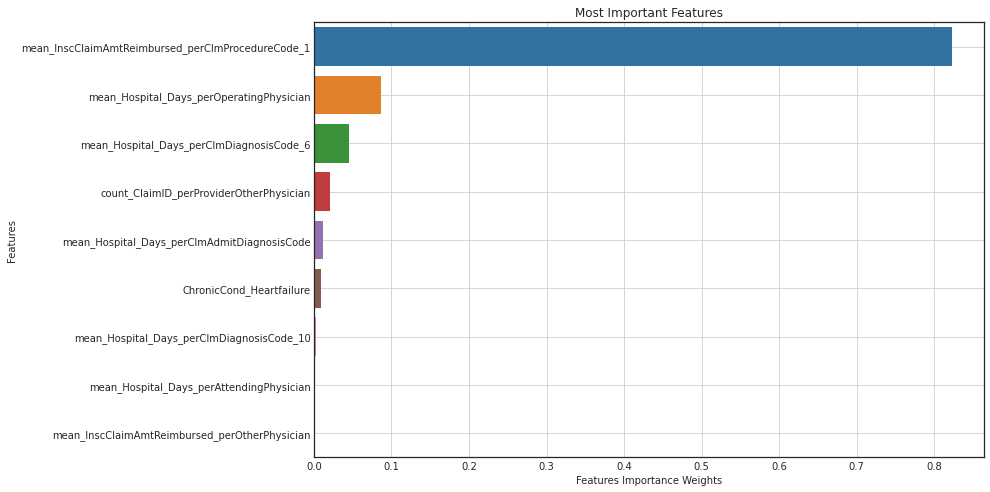

In [70]:
feat_weights = list(model3.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')                     # function call

#### 7.2.2 Finding the least important features using decision trees with best hyperparameters

                                            Features   Weights
0      mean_InscClaimAmtReimbursed_perOtherPhysician  0.000283
1           mean_Hospital_Days_perAttendingPhysician  0.001997
2          mean_Hospital_Days_perClmDiagnosisCode_10  0.002375
3                           ChronicCond_Heartfailure  0.008753
4        mean_Hospital_Days_perClmAdmitDiagnosisCode  0.012308
5            count_ClaimID_perProviderOtherPhysician  0.020732
6           mean_Hospital_Days_perClmDiagnosisCode_6  0.045054
7           mean_Hospital_Days_perOperatingPhysician  0.086056
8  mean_InscClaimAmtReimbursed_perClmProcedureCode_1  0.822440


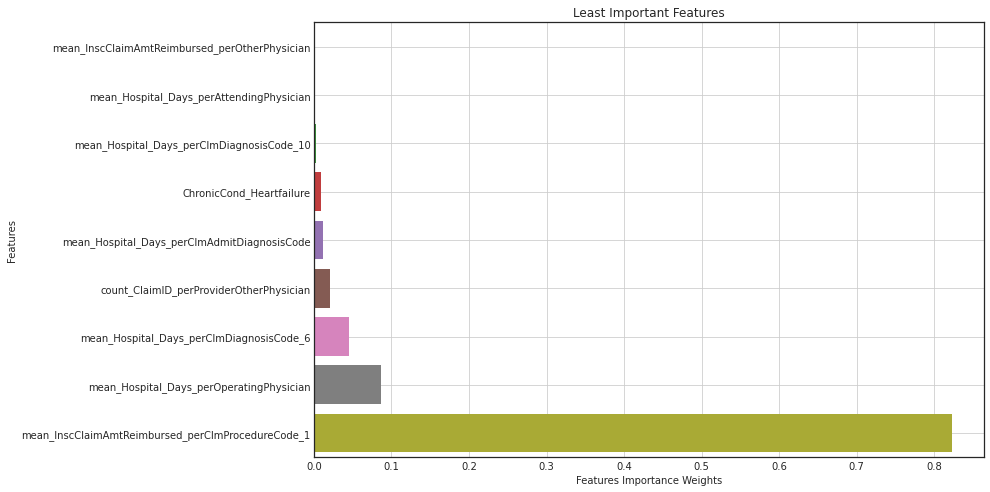

In [71]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')                # function call

#### 7.2.3 Summary of results and its comparison with other models

In [72]:
data.add_row(['Decision Trees', '70:30', 'Synthetic Minority Oversampling', 0.9376, 0.9351, 0.7731, 0.4955, 13])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

### 7.3 Fitting XGB Classifier with best hyperparameters

Train AUC = 0.9870159626751684
CV AUC = 0.9402438369888011


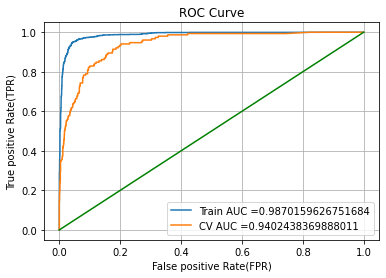

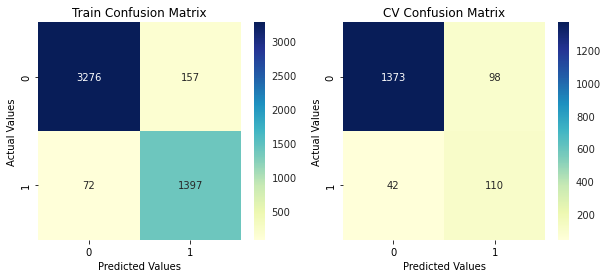

Best Threshold = 0.4617
Model AUC = 0.9402
Train F1 Score = 0.9242
CV F1 Score = 0.6111


In [73]:
model5 = XGBClassifier(n_estimators=263,
                       max_depth= 104,
                       colsample_bytree=0.83333,
                       reg_alpha=16,
                       reg_lambda=33,
                       random_state=49)

model5.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model5, X_train_std, X_cv_std, y_train, y_cv)         # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 7.3.1 Finding the most important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perOperatingPhysician  0.359717
1         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.319740
2        mean_DeductibleAmtPaid_perAttendingPhysician  0.054676
3            mean_Hospital_Days_perClmProcedureCode_1  0.044158
4            mean_Hospital_Days_perClmDiagnosisCode_5  0.025891
5        mean_DeductibleAmtPaid_perOperatingPhysician  0.015556
6            mean_Hospital_Days_perAttendingPhysician  0.014343
7                                              Race_5  0.009857
8                               ChronicCond_Alzheimer  0.009008
9                                              Race_3  0.007961
10           mean_Hospital_Days_perClmDiagnosisCode_9  0.007504
11                    count_ClaimID_perProviderBeneID  0.007118
12  mean_InscClaimAmtReimbursed_perClmProcedureCode_1  0.006855
13        count_ClaimID_perProviderClmDiagnosisCode_4  0.006738
14                              RenalDis

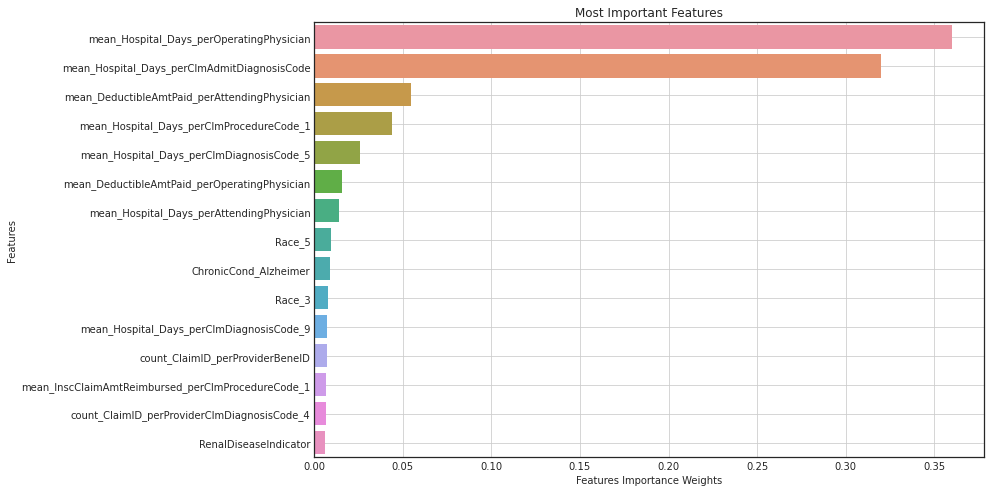

In [74]:
feat_weights = list(model5.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')            # function call

#### 7.3.2 Finding the least important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0                            ChronicCond_Heartfailure  0.001198
1            mean_Hospital_Days_perClmProcedureCode_2  0.001469
2   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3  0.001489
3             count_ClaimID_perProviderOtherPhysician  0.001605
4         count_ClaimID_perProviderClmDiagnosisCode_1  0.001683
5                                  ChronicCond_Cancer  0.001853
6                                            Gender_1  0.001993
7   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_4  0.002004
8                mean_Hospital_Days_perOtherPhysician  0.002050
9                          ChronicCond_ObstrPulmonary  0.002194
10           mean_DeductibleAmtPaid_perOtherPhysician  0.002211
11           mean_Hospital_Days_perClmDiagnosisCode_2  0.002212
12                           ChronicCond_Osteoporasis  0.002252
13                          ChronicCond_KidneyDisease  0.002260
14        count_ClaimID_perProviderAtten

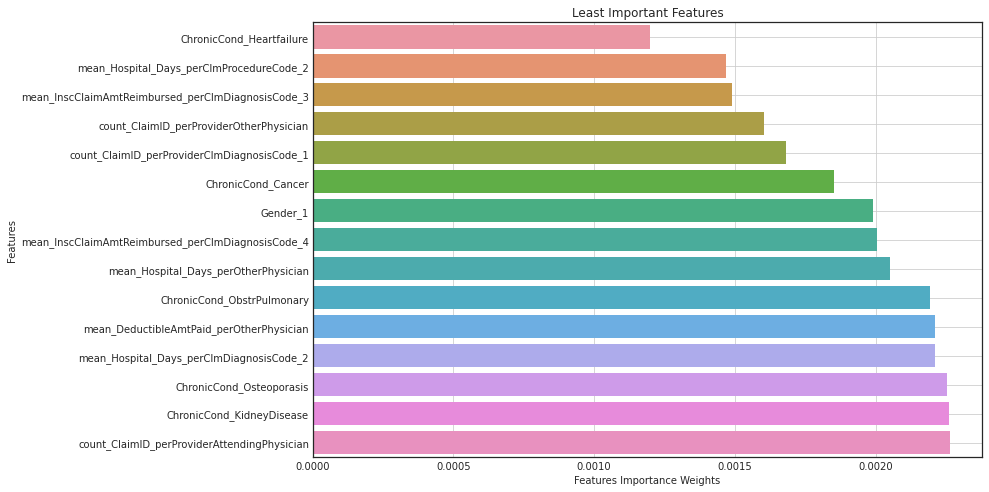

In [75]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')                # function call

#### 7.3.3 Summary of results and its comparison with other models

In [76]:
data.add_row(['XGBoost Classifier', '70:30', 'Synthetic Minority Oversampling', 0.9861, 0.9416, 0.9148, 0.6053, 37])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

## 8. Loading Data

### 8.1 Splitting and scaling data into Train and Cross Validation(or Test) 

#### 8.1.1 Stratified Sampling(80:20)

In [77]:
X_train_std, X_cv_std, y_train, y_cv, X_train_df, X_cv_df = train_cv_split_scaling(X, y, 0.20)        # function call

X_train Shape =  (4328, 285) 
X_cv Shape =  (1082, 285) 
Y_train Shape =  (4328,) 
Y_cv Shape =  (1082,)


### 8.2 SMOTE Sampling(80:20) for Imbalanced Data

In [78]:
# Code Reference: https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

oversample = SMOTE(sampling_strategy=0.25)
X_train_sample, y_train = oversample.fit_resample(X_train_std, y_train)
print(X_train_sample.shape, y_train.shape)
fraud_per(y_train)

(4903, 285) (4903,)
Fraud Percentage = 19.99% 
Non-Fraud Percentage = 80.01%


### 8.3 Perform Dimensionality Reduction Techniques

#### 8.3.1 Plot TSNE for Train Data (285 dimensions reduced to 2 dimension)

<Figure size 576x360 with 0 Axes>

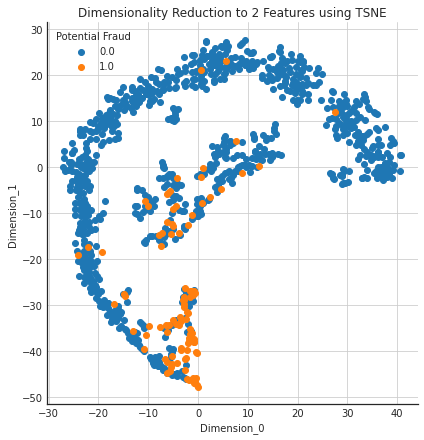

In [79]:
plot_TSNE(X_train_sample, y_train)                                       # function call

#### 8.3.2 Perform PCA for Feature Reduction

AUROC scores for different values of features:
 [0.9035259578813395, 0.9130037664086664, 0.9092598402667813, 0.9088289354900769, 0.9086359656262797, 0.9088473358886702, 0.9092482105242388, 0.9091413106214205, 0.9089933674702658, 0.9091464286947556, 0.9091923310295836, 0.9089401765057001, 0.9089957970135117, 0.909449862613646, 0.9091439991515099, 0.909243351437747, 0.9091925900164272, 0.9092943718459103, 0.9091923310295836, 0.9091952785465164, 0.9093453922540735, 0.9092409218945011, 0.9092460399678363, 0.9091439991515099, 0.9090929787433465, 0.9092943718459103]


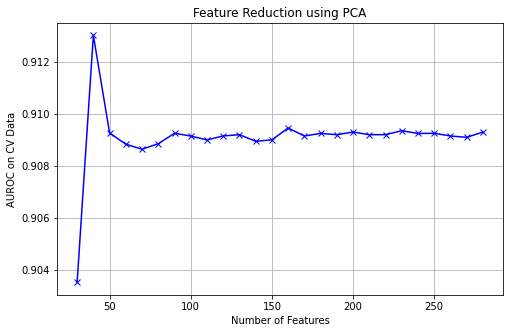

In [80]:
feat_reduct_PCA(X_train_sample, X_cv_std, y_cv)                            # function call

#### 8.3.3 Replace Train and CV(Test) Data with the best features

In [81]:
X_train_df = pd.DataFrame(X_train_sample, columns=X.columns)
X_cv_df = pd.DataFrame(X_cv_std, columns=X.columns)
print(X_train_df.shape, X_cv_df.shape)

imp_feat, X_train_std, X_cv_std = feat_after_reduction(40, X_train_sample, X, X_train_df, X_cv_df)               # function call

(4903, 285) (1082, 285)
Explained Variance using PCA with randomized svd_solver:
 [8.88635208e-01 7.98509970e-02 2.17511004e-02 4.05528045e-03
 1.31723964e-03 6.84742778e-04 6.11071442e-04 4.19205927e-04
 3.78314110e-04 2.81241095e-04 2.53976511e-04 2.27061481e-04
 1.50986376e-04 1.21424428e-04 1.15480132e-04 1.01160129e-04
 9.50475846e-05 7.57127556e-05 6.58618154e-05 5.82135397e-05
 4.93983453e-05 4.75098350e-05 4.20121178e-05 3.94329747e-05
 3.47389855e-05 3.27735036e-05 3.08747117e-05 2.95726591e-05
 2.51926811e-05 2.40680092e-05 2.28911827e-05 2.21205271e-05
 2.12815117e-05 1.98097064e-05 1.82563558e-05 1.76108067e-05
 1.67957984e-05 1.55715237e-05 1.44830944e-05 1.29137041e-05]


100%|██████████| 40/40 [00:00<00:00, 22072.38it/s]


Unique Feature Names with best Explained Variance Ratio:
 ['ChronicCond_rheumatoidarthritis', 'Claim_Days', 'mean_Hospital_Days_perClmDiagnosisCode_3', 'mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3', 'mean_InscClaimAmtReimbursed_perOperatingPhysician', 'mean_Hospital_Days_perClmAdmitDiagnosisCode', 'Race_3', 'mean_Claim_Days_perOperatingPhysician', 'count_ClaimID_perProviderAttendingPhysician', 'mean_DeductibleAmtPaid_perBeneID', 'mean_Hospital_Days_perClmDiagnosisCode_10', 'mean_Hospital_Days_perOperatingPhysician', 'mean_Hospital_Days_perOtherPhysician', 'mean_Hospital_Days_perClmDiagnosisCode_8', 'Race_2', 'mean_Hospital_Days_perClmDiagnosisCode_7', 'mean_Hospital_Days_perClmDiagnosisCode_4', 'Difference', 'ChronicCond_ObstrPulmonary', 'mean_Hospital_Days_perClmDiagnosisCode_6', 'count_ClaimID_perProviderClmDiagnosisCode_4', 'mean_Hospital_Days_perClmDiagnosisCode_9', 'RenalDiseaseIndicator', 'Gender_0', 'mean_Hospital_Days_perAttendingPhysician', 'mean_InscClaimAmtReimbursed_

#### 8.3.4 Store the Train and CV(Test) Data as csv for future use

In [82]:
X_train_std_df = pd.DataFrame(X_train_std, columns=imp_feat)                   # store Final X_train as dataframe 
X_cv_std_df = pd.DataFrame(X_cv_std, columns=imp_feat)                         # store Final X_cv as dataframe 
x_pf = pd.DataFrame(y_train, columns = ['PotentialFraud'])
X_train_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                # store y_train in Final X_train dataframe
x_pf = pd.DataFrame(y_cv, columns = ['PotentialFraud'])
X_cv_std_df['PotentialFraud'] = list(x_pf['PotentialFraud'])                   # store y_cv in Final X_cv dataframe

X_train_std_df.to_csv('Final_train4.csv', index = False)                       # store important features as csv for X_train
X_cv_std_df.to_csv('Final_cv4.csv', index = False)                             # store important features as csv for X_cv

## 9. Modelling with Synthetic Minority Oversampling
### 9.1 Fitting logistic regression with best hyperparameters

Train AUC = 0.946555374635197
CV AUC = 0.9392920943470494


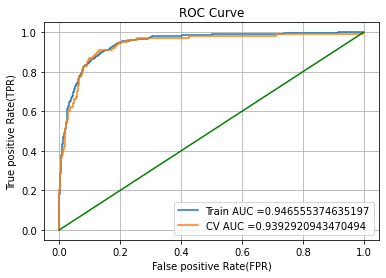

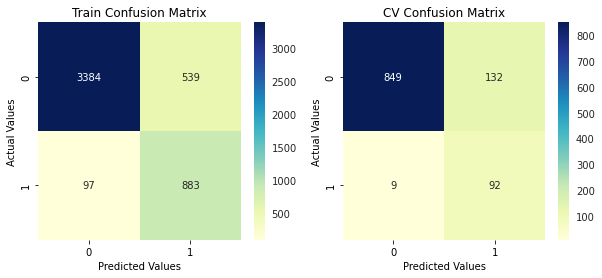

Best Threshold = 0.3260
Model AUC = 0.9393
Train F1 Score = 0.7352
CV F1 Score = 0.5662


In [83]:
model1 = LogisticRegression(penalty='l2',
                            C=0.443062,
                            tol=0.0001,
                            fit_intercept=True,
                            class_weight='balanced',
                            random_state=49,
                            solver='liblinear',  
                            max_iter=200)

model1.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model1, X_train_std, X_cv_std, y_train, y_cv)      # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 9.1.1 Finding the most important features using logistic regression with best hyperparameters

                                             Features   Weights
0   mean_InscClaimAmtReimbursed_perOperatingPhysician  3.165144
1                     count_ClaimID_perProviderBeneID  1.732244
2            mean_DeductibleAmtPaid_perOtherPhysician  1.192385
3            mean_Hospital_Days_perAttendingPhysician  1.146942
4            mean_Hospital_Days_perClmDiagnosisCode_5  1.112996
5            mean_Hospital_Days_perOperatingPhysician  1.068875
6         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.870597
7                               RenalDiseaseIndicator  0.863243
8         count_ClaimID_perProviderClmDiagnosisCode_4  0.782235
9         count_ClaimID_perProviderClmDiagnosisCode_2  0.756037
10           mean_Hospital_Days_perClmDiagnosisCode_2  0.584349
11                         ChronicCond_ObstrPulmonary  0.554651
12           mean_Hospital_Days_perClmDiagnosisCode_9  0.533397
13                                             Race_3  0.458222
14        count_ClaimID_perProviderAtten

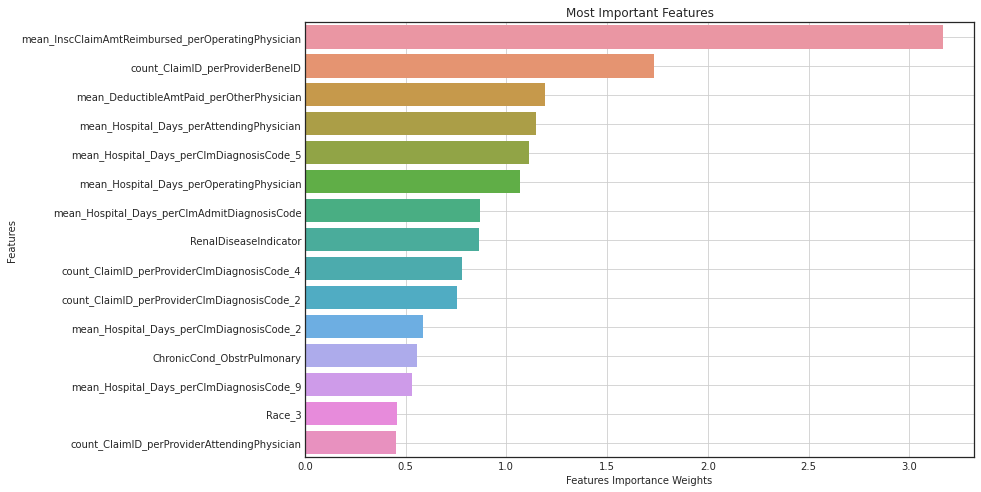

In [84]:
feat_weights = list(model1.coef_[0])
imp_features(imp_feat, feat_weights, False, 'Most Important ')           # function call

#### 9.1.2 Finding the least important features using logistic regression with best hyperparameters

                                             Features   Weights
0        mean_DeductibleAmtPaid_perOperatingPhysician -1.373731
1            mean_Hospital_Days_perClmDiagnosisCode_3 -1.119677
2                mean_Hospital_Days_perOtherPhysician -1.004654
3   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3 -1.002442
4   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_9 -0.811767
5                               ChronicCond_Alzheimer -0.740360
6                     ChronicCond_rheumatoidarthritis -0.714809
7   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_4 -0.697334
8            mean_Hospital_Days_perClmDiagnosisCode_4 -0.614796
9                                              Race_2 -0.473042
10                                           Gender_0 -0.410689
11           mean_Hospital_Days_perClmDiagnosisCode_6 -0.381142
12                   mean_DeductibleAmtPaid_perBeneID -0.365097
13                                             Race_1 -0.344177
14              mean_Claim_Days_perOpera

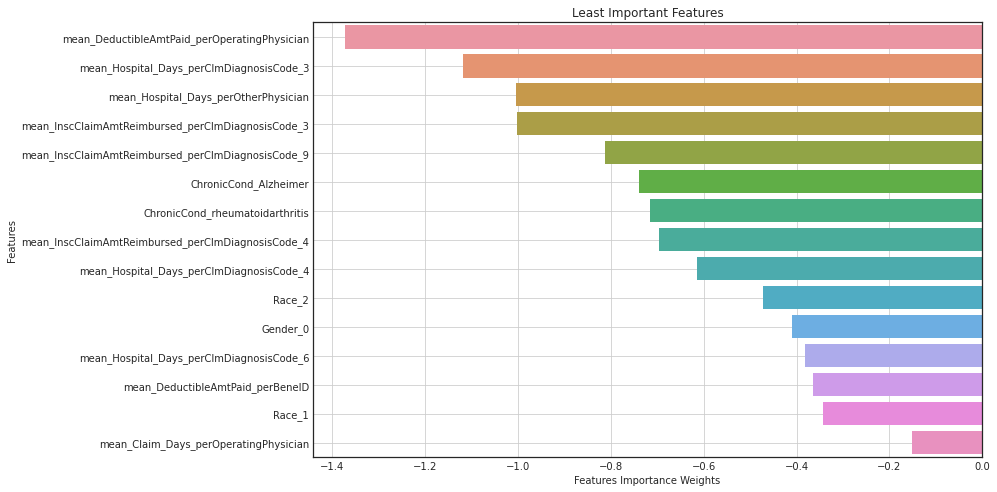

In [85]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')          # function call

#### 9.1.3 Summary of results and its comparison with other models

In [86]:
data.add_row(['Logistic Regression', '80:20', 'Synthetic Minority Oversampling', 0.9466, 0.9392, 0.7352, 0.5662, 9])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

### 9.2 Fitting decision trees with best hyperparameters

Train AUC = 0.9338681610803893
CV AUC = 0.9156599146153147


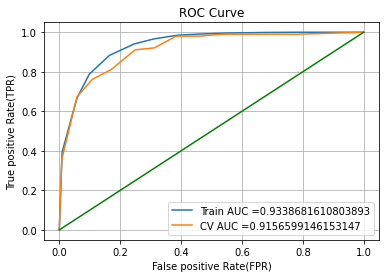

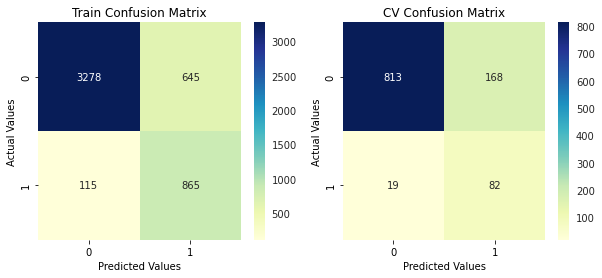

Best Threshold = 0.5897
Model AUC = 0.9157
Train F1 Score = 0.6948
CV F1 Score = 0.4672


In [87]:
model3 = DecisionTreeClassifier(criterion='gini',
                                max_depth= 178,
                                min_samples_split=122,
                                min_samples_leaf=280,
                                max_features='auto',
                                random_state=49,
                                class_weight='balanced')

model3.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model3, X_train_std, X_cv_std, y_train, y_cv)       # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 9.2.1 Finding the most important features using decision trees with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perClmDiagnosisCode_4  0.742310
1         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.093720
2            mean_Hospital_Days_perClmDiagnosisCode_8  0.075051
3                                            Gender_0  0.032034
4         count_ClaimID_perProviderAttendingPhysician  0.028079
5            mean_Hospital_Days_perClmDiagnosisCode_2  0.012801
6            mean_Hospital_Days_perOperatingPhysician  0.009798
7   mean_InscClaimAmtReimbursed_perOperatingPhysician  0.004954
8   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_9  0.000820
9                                          Claim_Days  0.000287
10                    count_ClaimID_perProviderBeneID  0.000147


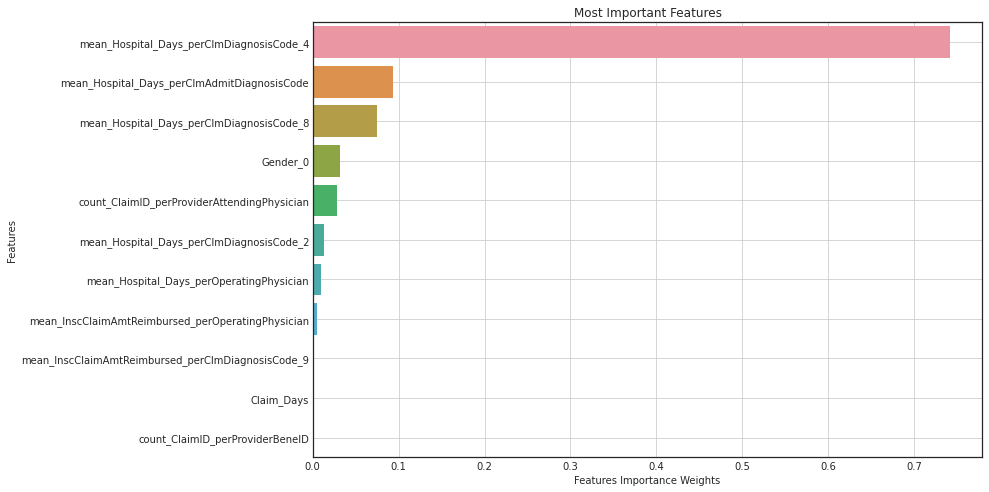

In [88]:
feat_weights = list(model3.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')            # function call

#### 9.2.2 Finding the least important features using decision trees with best hyperparameters

                                             Features   Weights
0                     count_ClaimID_perProviderBeneID  0.000147
1                                          Claim_Days  0.000287
2   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_9  0.000820
3   mean_InscClaimAmtReimbursed_perOperatingPhysician  0.004954
4            mean_Hospital_Days_perOperatingPhysician  0.009798
5            mean_Hospital_Days_perClmDiagnosisCode_2  0.012801
6         count_ClaimID_perProviderAttendingPhysician  0.028079
7                                            Gender_0  0.032034
8            mean_Hospital_Days_perClmDiagnosisCode_8  0.075051
9         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.093720
10           mean_Hospital_Days_perClmDiagnosisCode_4  0.742310


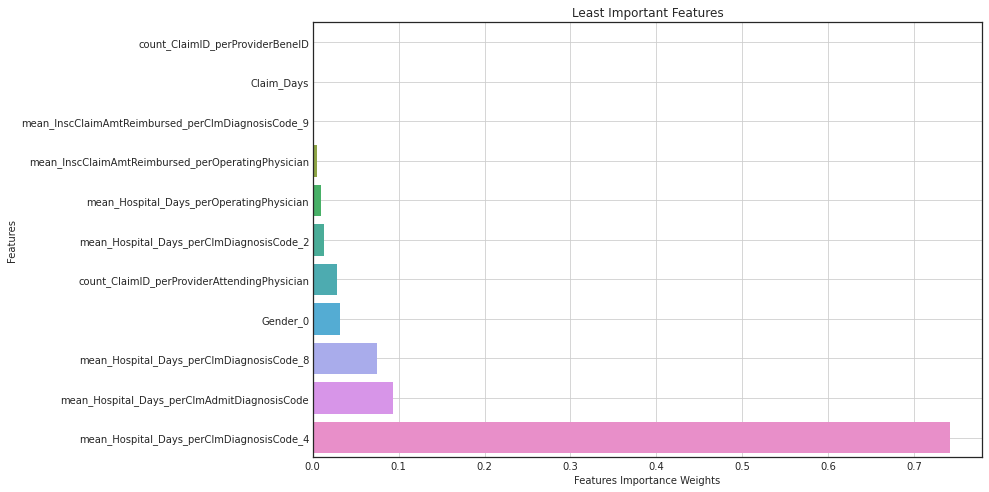

In [89]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')          # function call

#### 9.2.3 Summary of results and its comparison with other models

In [90]:
data.add_row(['Decision Trees', '80:20', 'Synthetic Minority Oversampling', 0.9318, 0.9344, 0.7251, 0.5531, 15])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

### 9.3 Fitting XGB Classifier with best hyperparameters

Train AUC = 0.9777865492360596
CV AUC = 0.9411138361542577


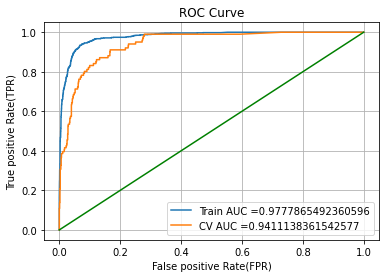

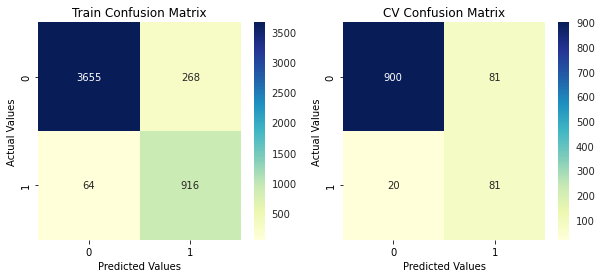

Best Threshold = 0.3243
Model AUC = 0.9411
Train F1 Score = 0.8466
CV F1 Score = 0.6160


In [91]:
model5 = XGBClassifier(n_estimators= 263,
                       max_depth= 104,
                       colsample_bytree=0.83333,
                       reg_alpha=16,
                       reg_lambda=33,
                       random_state=49)

model5.fit(X_train_std, y_train)

best_t, model_auc, train_f1_score, cv_f1_score = model_validation(model5, X_train_std, X_cv_std, y_train, y_cv)      # function call
print('Best Threshold = {:.4f}'.format(best_t))
print('Model AUC = {:.4f}'.format(model_auc))
print('Train F1 Score = {:.4f}'.format(train_f1_score))
print('CV F1 Score = {:.4f}'.format(cv_f1_score))

#### 9.3.1 Finding the most important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perOperatingPhysician  0.531549
1   mean_InscClaimAmtReimbursed_perOperatingPhysician  0.119073
2            mean_Hospital_Days_perAttendingPhysician  0.057206
3         count_ClaimID_perProviderClmDiagnosisCode_4  0.034337
4            mean_Hospital_Days_perClmDiagnosisCode_5  0.028830
5         mean_Hospital_Days_perClmAdmitDiagnosisCode  0.028723
6        mean_DeductibleAmtPaid_perOperatingPhysician  0.026600
7            mean_Hospital_Days_perClmDiagnosisCode_9  0.018115
8                     count_ClaimID_perProviderBeneID  0.017193
9         count_ClaimID_perProviderClmDiagnosisCode_2  0.009527
10                                           Gender_0  0.008977
11           mean_Hospital_Days_perClmDiagnosisCode_2  0.008915
12                              ChronicCond_Alzheimer  0.008138
13  mean_InscClaimAmtReimbursed_perClmDiagnosisCode_4  0.007962
14                                      

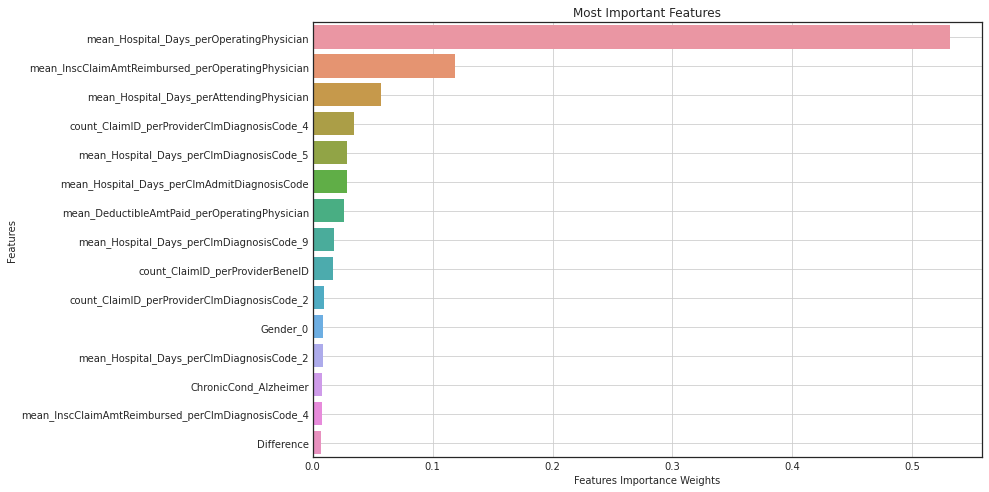

In [92]:
feat_weights = list(model5.feature_importances_)

imp_features(imp_feat, feat_weights, False, 'Most Important ')           # function call

#### 9.3.2 Finding the least important features using XGB Classifier with best hyperparameters

                                             Features   Weights
0            mean_Hospital_Days_perClmDiagnosisCode_7  0.002132
1   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_3  0.002154
2   mean_InscClaimAmtReimbursed_perClmDiagnosisCode_9  0.002186
3                    mean_DeductibleAmtPaid_perBeneID  0.002558
4            mean_Hospital_Days_perClmDiagnosisCode_4  0.002632
5                            OPAnnualReimbursementAmt  0.002781
6                                          Claim_Days  0.002861
7                                              Race_1  0.003058
8                     ChronicCond_rheumatoidarthritis  0.003113
9               mean_Claim_Days_perOperatingPhysician  0.003124
10           mean_DeductibleAmtPaid_perOtherPhysician  0.003327
11                             ChronicCond_Depression  0.003388
12        count_ClaimID_perProviderAttendingPhysician  0.003400
13          mean_Hospital_Days_perClmDiagnosisCode_10  0.003406
14            mean_OPAnnualReimbursement

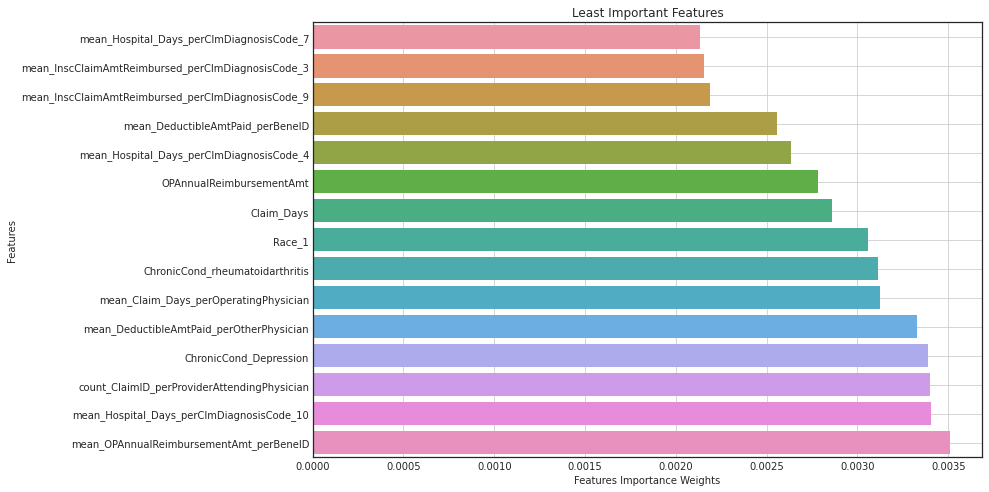

In [93]:
imp_features(imp_feat, feat_weights, True, 'Least Important ')          # function call

#### 9.3.3 Summary of results and its comparison with other models

In [94]:
data.add_row(['XGBoost Classifier', '80:20', 'Synthetic Minority Oversampling', 0.9767, 0.9417, 0.8333, 0.6029, 19])

print(data)

+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
|        Model        | Sampling Ratio |   Solution for Imbalanced Data  | Train AUC | CV AUC | Train F1 Score | CV F1 Score | False Negatives |
+---------------------+----------------+---------------------------------+-----------+--------+----------------+-------------+-----------------+
| Logistic Regression |     70:30      |     Class Weight = Balanced     |   0.9406  | 0.9532 |     0.5751     |    0.6044   |        16       |
|    Decision Trees   |     70:30      |     Class Weight = Balanced     |   0.9251  | 0.9281 |     0.5307     |    0.5473   |        16       |
|  XGBoost Classifier |     70:30      |      Scale Positive Weight      |   0.9839  | 0.9499 |     0.786      |    0.6431   |        34       |
| Logistic Regression |     80:20      |     Class Weight = Balanced     |   0.9435  | 0.9482 |     0.6103     |    0.5979   |    

## 10. Conclusion from Model Training

1. The following aggregated features are <b>useful</b> in achieving good model performance:
<ol type = 'a'>
<li>Attending Physician</li> 
<li>Operating Physician</li>
<li>Other Physician</li>
<li>Hospitalization Days</li>
<li>Provider</li>
<li>Claim Days</li>
<li>Beneficiary ID</li>
<li>Renal Disease Indicator</li>
<li>Diagnostic Codes(2,4,5,8,9)</li> 
<li>Race_3</li>
<li>Insurance Claim Reimbursement Amount</li>
</ol>
2. The above mentioned Aggregated features(that capture the interactions b/w the different parties involved in the <b>Claim</b> process have certainly helped in achieving the <b>good performance scores</b>.
3. <b>Synthetic Minority Oversampling</b> <u>doesn't provide gain</u> in the model's performance. Hence, this is not of much use.
4. As of now, <b>Logistic Regression</b> with <u>Class Weight = Balanced and 70:30 Train CV Split</u> is working <b>best</b> from the modelling carried out so far.